#**Imports and setup**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')

#**Data Loading and Datetime Parsing**

In [3]:
# Load raw training and testing data
train_df = pd.read_csv('train_raw.csv')
test_df = pd.read_csv('test_raw.csv')

# Merge train and test datasets
df = pd.concat([train_df, test_df], ignore_index=True)

# Create a proper datetime column and sort the dataset
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values(by=['station', 'date']).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (420768, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [4]:
#**Exploratory Data Analysis & Visualizations**

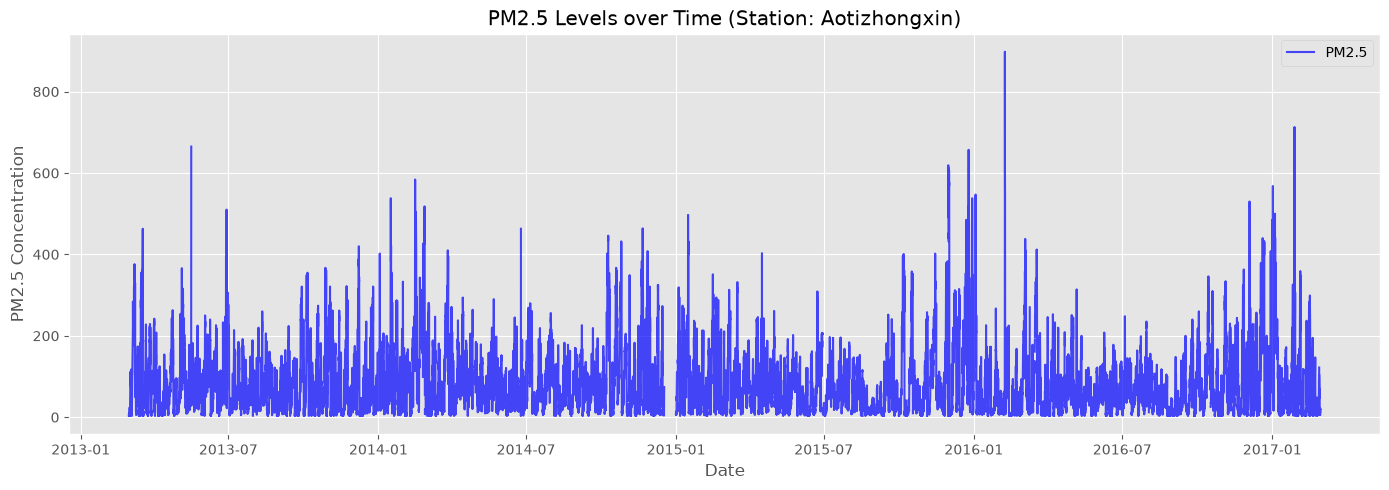

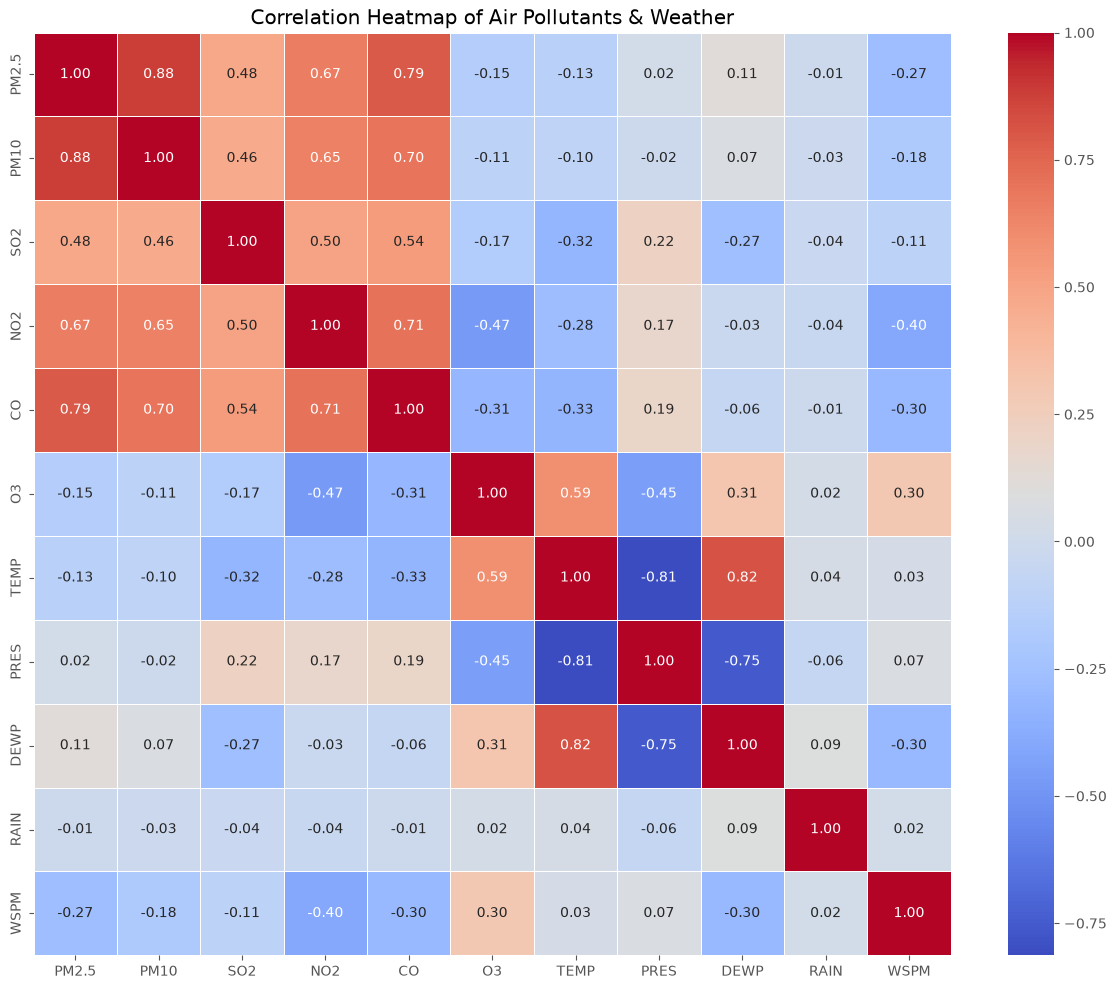

In [5]:
# 1. Plot PM2.5 Time Series for a single station (e.g., Aotizhongxin)
plt.figure(figsize=(14, 5))
sample_station = df[df['station'] == 'Aotizhongxin']
plt.plot(sample_station['date'], sample_station['PM2.5'], label='PM2.5', color='blue', alpha=0.7)
plt.title('PM2.5 Levels over Time (Station: Aotizhongxin)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Fixed: Only using numeric columns)
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Exclude structural columns from heatmap
heatmap_cols = [c for c in numeric_cols if c not in ['No', 'year', 'month', 'day', 'hour']]

sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Air Pollutants & Weather')
plt.tight_layout()
plt.show()

In [6]:
#**Station-Aware Missing Value Imputation**

In [7]:
# Group by station to prevent cross-contamination during imputation
def impute_missing(group):
    # Interpolate forward, then backward fill remaining NaNs at the start
    return group.interpolate(method='linear', limit_direction='forward').bfill()

# Apply the imputation station by station
df = df.groupby('station', group_keys=False).apply(impute_missing)

# Check to ensure no missing values remain
print("Missing values after station-aware imputation:")
print(df.isnull().sum())

Missing values after station-aware imputation:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


In [8]:
#**Feature Engineering**

In [9]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

# -----------------------------------------------------
# 1. PM2.5 Lag Features
# -----------------------------------------------------
lags = [1, 2, 3, 6, 12, 24]

for lag in lags:
    df[f'PM25_lag_{lag}'] = (
        df.groupby('station')['PM2.5'].shift(lag)
    )


# -----------------------------------------------------
# 2. Rolling Statistics (Mean/Std & Min/Max/Median)
# -----------------------------------------------------
windows = [3, 6, 12, 24]

for w in windows:

    df[f'PM25_roll_mean_{w}'] = (
    df.groupby('station')['PM2.5']
      .transform(lambda x: x.shift(1).rolling(window=w).mean())
    )
    
    df[f'PM25_roll_std_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.shift(1).rolling(window=w).std())
    )

    
    
    # MOVED UP: Min, Max, and Median calculated immediately after Std
    df[f'PM25_roll_min_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(
              lambda x: x.shift(1).rolling(w).min()
          )
    )

    df[f'PM25_roll_max_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(
              lambda x: x.shift(1).rolling(w).max()
          )
    )

    df[f'PM25_roll_median_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(
              lambda x: x.shift(1).rolling(w).median()
          )
    )

# -----------------------------------------------------
# 2B. Exponential Moving Average Features
# -----------------------------------------------------
ewm_spans = [3, 6, 12, 24]

for span in ewm_spans:

    df[f'PM25_ewm_mean_{span}'] = (
        df.groupby('station')['PM2.5']
          .transform(
              lambda x: x.shift(1)
                        .ewm(span=span, adjust=False)
                        .mean()
          )
    )


# -----------------------------------------------------
# 3. Difference Features
# -----------------------------------------------------
df['PM25_diff1'] = (
    df.groupby('station')['PM2.5']
      .transform(lambda x: x.shift(1).diff(1))
)

df['PM25_diff24'] = (
    df.groupby('station')['PM2.5']
      .transform(lambda x: x.shift(1).diff(24))
)


#### Rolling quantitles

for w in windows:

    df[f'PM25_roll_q25_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.shift(1).rolling(w).quantile(0.25))
    )

    df[f'PM25_roll_q75_{w}'] = (
        df.groupby('station')['PM2.5']
          .transform(lambda x: x.shift(1).rolling(w).quantile(0.75))
    )

    

# -----------------------------------------------------
# 4. Fill NaNs Created by Lag/Rolling/Diff
# -----------------------------------------------------
df = df.groupby('station', group_keys=False).apply(
    lambda x: x.ffill().bfill()
)


# -----------------------------------------------------
# 4B. Rolling CV (Calculated AFTER filling NaNs)
# -----------------------------------------------------
for w in windows:
    df[f'PM25_cv_{w}'] = (
        df[f'PM25_roll_std_{w}'] /
        (df[f'PM25_roll_mean_{w}'] + 1e-6)
    )



    
# -----------------------------------------------------
# 5. Cyclic Time Features
# -----------------------------------------------------
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['weekday'] = df['date'].dt.weekday

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)


# -----------------------------------------------------
# 6. Wind Direction Encoding
# -----------------------------------------------------
df['wd'] = df['wd'].ffill().bfill()

wd_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

df['wd_angle'] = df['wd'].map(wd_map)

df['wd_sin'] = np.sin(np.radians(df['wd_angle']))
df['wd_cos'] = np.cos(np.radians(df['wd_angle']))


# -----------------------------------------------------
# 7. Station One-Hot Encoding
# -----------------------------------------------------
station_dummies = pd.get_dummies(
    df['station'],
    prefix='station',
    dtype=float
)

df = pd.concat([df, station_dummies], axis=1)

station_cols = [
    col for col in df.columns
    if col.startswith('station_')
]


# -----------------------------------------------------
# 8. Ratio & Interaction Features (Moved before Feature Lists)
# -----------------------------------------------------
eps = 1e-6

df['PM25_PM10_ratio'] = df['PM2.5'] / (df['PM10'] + eps)

df['NO2_SO2_ratio'] = df['NO2'] / (df['SO2'] + eps)

df['CO_O3_ratio'] = df['CO'] / (df['O3'] + eps)

df['PM10_minus_PM25'] = df['PM10'] - df['PM2.5']

df['TEMP_DEWP'] = df['TEMP'] * df['DEWP']
df['TEMP_WSPM'] = df['TEMP'] * df['WSPM']
df['CO_WSPM'] = df['CO'] * df['WSPM']
df['NO2_O3'] = df['NO2'] * df['O3']
df['TEMP_hour'] = df['TEMP'] * df['hour_sin']
df['PRES_TEMP'] = df['PRES'] * df['TEMP']


# -----------------------------------------------------
# 9. Feature Lists
# -----------------------------------------------------
base_features = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

lag_features = [
    f'PM25_lag_{lag}'
    for lag in lags
]



rolling_features = []

for w in windows:
    rolling_features.extend([
        f'PM25_roll_mean_{w}',
        f'PM25_roll_std_{w}',
        f'PM25_roll_min_{w}',
        f'PM25_roll_max_{w}',
        f'PM25_roll_median_{w}'
    ])

# DELETED: Duplicate block appending roll_mean and roll_std

ewm_features = [
    f'PM25_ewm_mean_{span}'
    for span in ewm_spans
]

cv_features = [
    f'PM25_cv_{w}'
    for w in windows
]

quantile_features = []

for w in windows:
    quantile_features.extend([
        f'PM25_roll_q25_{w}',
        f'PM25_roll_q75_{w}'
    ])

    
diff_features = [
    'PM25_diff1',
    'PM25_diff24'
]

wind_features = [
    'wd_sin',
    'wd_cos'
]

time_features = [
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'weekday_sin',
    'weekday_cos'
]

ratio_features = [
    'PM25_PM10_ratio',
    'NO2_SO2_ratio',
    'CO_O3_ratio',
    'PM10_minus_PM25'
]

interaction_features = [
    'TEMP_DEWP',
    'TEMP_WSPM',
    'CO_WSPM',
    'NO2_O3',
    'TEMP_hour',
    'PRES_TEMP'
]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df.groupby("station", group_keys=False).apply(
    lambda x: x.ffill().bfill()
)

all_features = (
    base_features +
    lag_features +
    rolling_features +
    ewm_features +
    cv_features +
    quantile_features +
    ratio_features +
    interaction_features +
    diff_features +
    wind_features +
    station_cols +
    time_features
)

In [10]:
#**Chronological Train & Validation Split**

In [11]:
split_date = '2016-03-01'

train_df = df[df['date'] < split_date].copy()
val_df = df[df['date'] >= split_date].copy()

print("Training:")
print(train_df['date'].min(), "to", train_df['date'].max())

print("\nValidation:")
print(val_df['date'].min(), "to", val_df['date'].max())

print("\nRows:")
print("Train:", len(train_df))
print("Validation:", len(val_df))

Training:
2013-03-01 00:00:00 to 2016-02-29 23:00:00

Validation:
2016-03-01 00:00:00 to 2017-02-28 23:00:00

Rows:
Train: 315648
Validation: 105120


In [12]:
# -----------------------------------------------------
# 11. Create station_hour_mean AFTER splitting
# -----------------------------------------------------
hour_station_mean = (
    train_df.groupby(['station','hour'])['PM2.5']
    .mean()
)

global_hour_mean = (
    train_df.groupby('hour')['PM2.5']
    .mean()
)

train_df['station_hour_mean'] = (
    train_df.set_index(['station','hour'])
    .index.map(hour_station_mean)
)

val_df['station_hour_mean'] = (
    val_df.set_index(['station','hour'])
    .index.map(hour_station_mean)
)

train_df['station_hour_mean'] = train_df[
    'station_hour_mean'
].fillna(
    train_df['hour'].map(global_hour_mean)
)

val_df['station_hour_mean'] = val_df[
    'station_hour_mean'
].fillna(
    val_df['hour'].map(global_hour_mean)
)


# -----------------------------------------------------
# 12. Final Feature List Append
# -----------------------------------------------------
all_features.append("station_hour_mean")
target = 'PM2.5'

print(f"Total Features: {len(all_features)}")
print(all_features)

Total Features: 86
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24', 'PM25_roll_mean_3', 'PM25_roll_std_3', 'PM25_roll_min_3', 'PM25_roll_max_3', 'PM25_roll_median_3', 'PM25_roll_mean_6', 'PM25_roll_std_6', 'PM25_roll_min_6', 'PM25_roll_max_6', 'PM25_roll_median_6', 'PM25_roll_mean_12', 'PM25_roll_std_12', 'PM25_roll_min_12', 'PM25_roll_max_12', 'PM25_roll_median_12', 'PM25_roll_mean_24', 'PM25_roll_std_24', 'PM25_roll_min_24', 'PM25_roll_max_24', 'PM25_roll_median_24', 'PM25_ewm_mean_3', 'PM25_ewm_mean_6', 'PM25_ewm_mean_12', 'PM25_ewm_mean_24', 'PM25_cv_3', 'PM25_cv_6', 'PM25_cv_12', 'PM25_cv_24', 'PM25_roll_q25_3', 'PM25_roll_q75_3', 'PM25_roll_q25_6', 'PM25_roll_q75_6', 'PM25_roll_q25_12', 'PM25_roll_q75_12', 'PM25_roll_q25_24', 'PM25_roll_q75_24', 'PM25_PM10_ratio', 'NO2_SO2_ratio', 'CO_O3_ratio', 'PM10_minus_PM25', 'TEMP_DEWP', 'TEMP_WSPM', 'CO_WSPM', 'NO2_O3', 

In [13]:
#**Scaling and Target Transformation**

In [14]:
# Initialize Scalers
feature_scaler = MinMaxScaler()
# We need a separate scaler for the target so we can inverse_transform later
target_scaler = MinMaxScaler()

# ❌ REMOVED: np.log1p() transformations completely.

# Fit scalers on TRAINING data only
train_df[all_features] = feature_scaler.fit_transform(train_df[all_features])

# ✅ Scale the RAW PM2.5 target directly
train_df[['PM2.5_scaled']] = target_scaler.fit_transform(train_df[['PM2.5']])

# Transform VALIDATION data
val_df[all_features] = feature_scaler.transform(val_df[all_features])
val_df[['PM2.5_scaled']] = target_scaler.transform(val_df[['PM2.5']])

In [15]:
#**24-Hour Sequence Generation**

In [16]:
def create_sequences_per_station(data, feature_cols, target_col, window_size=24):
    X, y = [], []
    # Group by station to ensure windows don't cross station boundaries
    for station_name, group in data.groupby('station'):
        group_features = group[feature_cols].values
        group_target = group[target_col].values

        for i in range(len(group) - window_size):
            X.append(group_features[i : i + window_size])
            y.append(group_target[i + window_size])

    return np.array(X), np.array(y)

window_size = 24

# Create Train Sequences
print("Generating training sequences...")
X_train, y_train = create_sequences_per_station(
    train_df,
    feature_cols=all_features,
    target_col='PM2.5_scaled', #PM2.5_log_scaled
    window_size=window_size
)

# Create Validation Sequences
print("Generating validation sequences...")
X_val, y_val = create_sequences_per_station(
    val_df,
    feature_cols=all_features,
    target_col='PM2.5_scaled',
    window_size=window_size
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Generating training sequences...
Generating validation sequences...
X_train shape: (315360, 24, 86)
y_train shape: (315360,)
X_val shape: (104832, 24, 86)
y_val shape: (104832,)


In [17]:
#**LSTM model**

In [18]:
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization

lstm_model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    keras.layers.Bidirectional(
        keras.layers.LSTM(256, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.15),

    keras.layers.Bidirectional(
        keras.layers.LSTM(64)
    ),
    BatchNormalization(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(64, activation="relu"),

    keras.layers.Dense(1)
])

lstm_model.summary()

optimizer = keras.optimizers.Adam(learning_rate=5e-4)

lstm_model.compile(
    optimizer=optimizer,
    loss="mse",   # Try MSE for lower RMSE
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.R2Score(name="r2")
    ]
)

I0000 00:00:1784925418.425196 1791396 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 23377 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:34:00.0, compute capability: 8.9
I0000 00:00:1784925418.426400 1791396 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 35888 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:70:00.0, compute capability: 8.9
I0000 00:00:1784925418.427617 1791396 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38140 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ca:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 512)        │       702,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 24, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,551,617 (5.92 MB)

 Trainable params: 1,549,825 (5.91 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [19]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(X_train.shape[1], X_train.shape[2]))

# CNN Feature Extraction
x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(inputs)

x = layers.BatchNormalization()(x)

# First BiLSTM
x = layers.Bidirectional(
    layers.LSTM(
        128,
        return_sequences=True
    )
)(x)

x = layers.Dropout(0.2)(x)

# Second BiLSTM
x = layers.Bidirectional(
    layers.LSTM(
        64,
        return_sequences=True
    )
)(x)

# Self-Attention
attention = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.1
)(x, x)

# Residual Connection
x = layers.Add()([x, attention])

# Layer Normalization
x = layers.LayerNormalization()(x)

# Global Pooling
x = layers.GlobalAveragePooling1D()(x)

# Dense Layers
x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

optimizer = keras.optimizers.Adam(
    learning_rate=5e-4
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.R2Score(name="r2")
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 86)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │     16,576 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 24, 256)   │    197,632 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 256)   │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 24, 128)   │    164,352 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │     66,048 │ bidirectional_4[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ bidirectional_4[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 453,441 (1.73 MB)

 Trainable params: 453,313 (1.73 MB)

 Non-trainable params: 128 (512.00 B)

Training LSTM model...
Epoch 1/100


I0000 00:00:1784925428.156815 2498368 cuda_dnn.cc:461] Loaded cuDNN version 92500


4928/4928 ━━━━━━━━━━━━━━━━━━━━ 289s 57ms/step - loss: 0.0044 - r2: 0.3195 - rmse: 0.0665 - val_loss: 5.5223e-04 - val_r2: 0.9195 - val_rmse: 0.0235 - learning_rate: 5.0000e-04
Epoch 2/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 262s 53ms/step - loss: 6.0086e-04 - r2: 0.9076 - rmse: 0.0245 - val_loss: 3.6987e-04 - val_r2: 0.9461 - val_rmse: 0.0192 - learning_rate: 5.0000e-04
Epoch 3/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 240s 49ms/step - loss: 4.8705e-04 - r2: 0.9251 - rmse: 0.0221 - val_loss: 4.5559e-04 - val_r2: 0.9336 - val_rmse: 0.0213 - learning_rate: 5.0000e-04
Epoch 4/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 250s 51ms/step - loss: 4.2391e-04 - r2: 0.9348 - rmse: 0.0206 - val_loss: 6.0371e-04 - val_r2: 0.9120 - val_rmse: 0.0246 - learning_rate: 5.0000e-04
Epoch 5/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 4.0085e-04 - r2: 0.9384 - rmse: 0.0200
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 285s 58ms/step - loss: 4.0085e-04 - r2

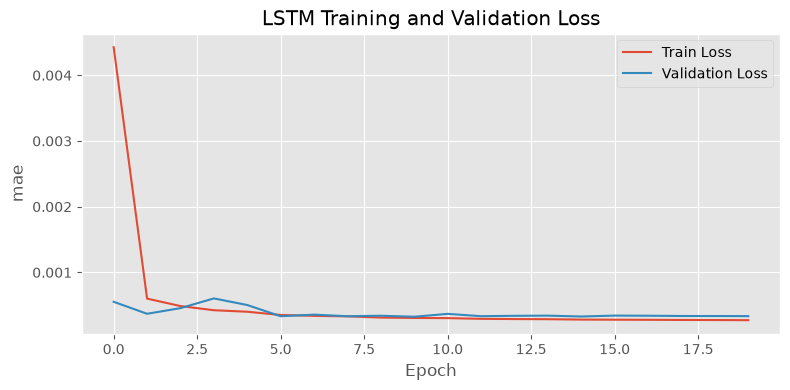

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the LSTM model
print("Training LSTM model...")

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,          # Try 64 if GPU memory allows
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('mae')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
from tensorflow.keras.layers import BatchNormalization

gru_model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

    keras.layers.Bidirectional(
        keras.layers.GRU(128, return_sequences=True)
    ),
    BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Bidirectional(
        keras.layers.GRU(64)
    ),
    BatchNormalization(),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1)
])

gru_model.summary()

gru_model.compile(
    optimizer="adam",
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.R2Score(name="r2")
    ]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_5 (Bidirectional) │ (None, 24, 256)        │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,393 (1.14 MB)

 Trainable params: 298,625 (1.14 MB)

 Non-trainable params: 768 (3.00 KB)

Training GRU model...
Epoch 1/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 208s 42ms/step - loss: 0.0044 - r2: -0.3815 - rmse: 0.0948 - val_loss: 2.5371e-04 - val_r2: 0.9261 - val_rmse: 0.0225 - learning_rate: 0.0010
Epoch 2/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 164s 33ms/step - loss: 3.5859e-04 - r2: 0.8898 - rmse: 0.0268 - val_loss: 2.2441e-04 - val_r2: 0.9346 - val_rmse: 0.0212 - learning_rate: 0.0010
Epoch 3/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 179s 36ms/step - loss: 3.2196e-04 - r2: 0.9010 - rmse: 0.0254 - val_loss: 2.0053e-04 - val_r2: 0.9416 - val_rmse: 0.0200 - learning_rate: 0.0010
Epoch 4/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.9225e-04 - r2: 0.9102 - rmse: 0.0242
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 200s 41ms/step - loss: 2.9225e-04 - r2: 0.9102 - rmse: 0.0242 - val_loss: 1.8416e-04 - val_r2: 0.9463 - val_rmse: 0.0192 - learning_rate: 0.0010
Epoch 5/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 202s 41ms/step - lo

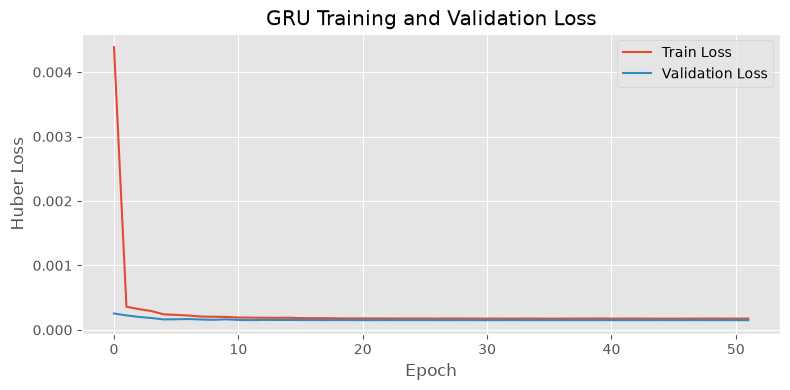

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the GRU model
print("Training GRU model...")

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.legend()

plt.tight_layout()
plt.show()

Training model...
Epoch 1/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 182s 36ms/step - loss: 0.0057 - r2: 0.1226 - rmse: 0.0756 - val_loss: 5.4528e-04 - val_r2: 0.9205 - val_rmse: 0.0234 - learning_rate: 5.0000e-04
Epoch 2/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 235s 48ms/step - loss: 7.7734e-04 - r2: 0.8805 - rmse: 0.0279 - val_loss: 5.7251e-04 - val_r2: 0.9166 - val_rmse: 0.0239 - learning_rate: 5.0000e-04
Epoch 3/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 228s 46ms/step - loss: 7.4928e-04 - r2: 0.8848 - rmse: 0.0274 - val_loss: 5.5928e-04 - val_r2: 0.9185 - val_rmse: 0.0236 - learning_rate: 5.0000e-04
Epoch 4/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 241s 49ms/step - loss: 7.1443e-04 - r2: 0.8902 - rmse: 0.0267 - val_loss: 3.9481e-04 - val_r2: 0.9425 - val_rmse: 0.0199 - learning_rate: 5.0000e-04
Epoch 5/100
4928/4928 ━━━━━━━━━━━━━━━━━━━━ 239s 49ms/step - loss: 6.3798e-04 - r2: 0.9019 - rmse: 0.0253 - val_loss: 3.8783e-04 - val_r2: 0.9435 - val_rmse: 0.0197 - learning_rate: 5.0000e-04
Epoch 6/100
4928/4928 ━━━━

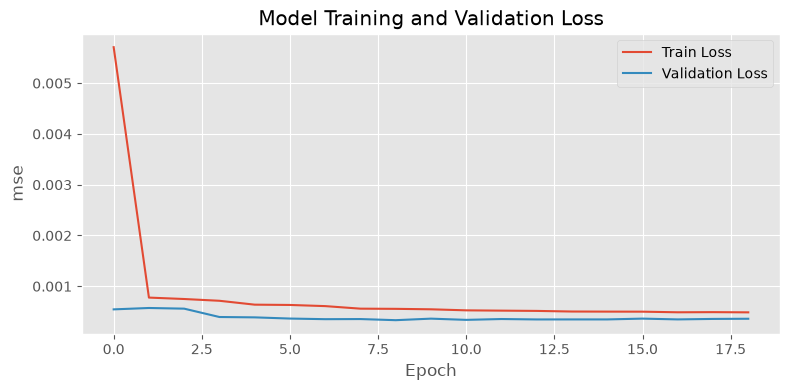

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the model
print("Training model...")

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('mse')
plt.legend()

plt.tight_layout()
plt.show()

Generating LSTM predictions...
410/410 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
Generating GRU predictions...
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Generating third model predictions...
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Calculating 3-model averaged ensemble predictions...
--- LSTM Model Performance ---
RMSE: 0.0180
MAE:  0.0103
R2:   0.9527

--- GRU Model Performance ---
RMSE: 0.0173
MAE:  0.0093
R2:   0.9562

--- Third Model Performance ---
RMSE: 0.0182
MAE:  0.0101
R2:   0.9515

--- 3-Model Averaged Ensemble Performance ---
RMSE: 0.0175
MAE:  0.0096
R2:   0.9555



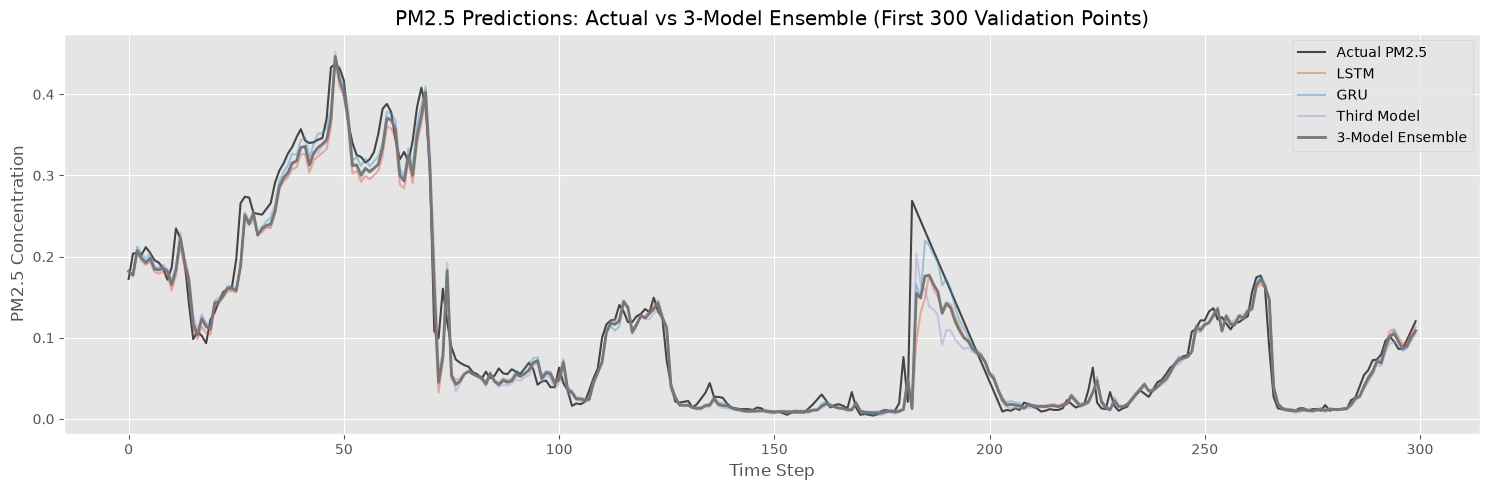

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Generate predictions for all three models separately
print("Generating LSTM predictions...")
lstm_preds_scaled = lstm_model.predict(X_val, batch_size=256)

print("Generating GRU predictions...")
gru_preds_scaled = gru_model.predict(X_val, batch_size=256)

print("Generating third model predictions...")
model_preds_scaled = model.predict(X_val, batch_size=256)


# 2. Average the predictions (3-model Ensemble)
print("Calculating 3-model averaged ensemble predictions...")

ensemble_preds_scaled = (
    lstm_preds_scaled +
    gru_preds_scaled +
    model_preds_scaled
) / 3.0


# 3. Inverse transform predictions back to original PM2.5 scale

lstm_preds = target_scaler.inverse_transform(lstm_preds_scaled)
gru_preds = target_scaler.inverse_transform(gru_preds_scaled)
model_preds = target_scaler.inverse_transform(model_preds_scaled)

ensemble_preds = target_scaler.inverse_transform(ensemble_preds_scaled)


# Inverse transform actual validation targets
y_val_actual = target_scaler.inverse_transform(
    y_val.reshape(-1, 1)
)


# 4. Evaluation function
def evaluate_preds(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")


# Compare individual models + ensemble
evaluate_preds(y_val_actual, lstm_preds, "LSTM Model")
evaluate_preds(y_val_actual, gru_preds, "GRU Model")
evaluate_preds(y_val_actual, model_preds, "Third Model")

evaluate_preds(
    y_val_actual,
    ensemble_preds,
    "3-Model Averaged Ensemble"
)


# 5. Plot predictions
plt.figure(figsize=(15, 5))

plot_window = 300

plt.plot(
    y_val_actual[:plot_window],
    label='Actual PM2.5',
    color='black',
    alpha=0.7
)

plt.plot(
    lstm_preds[:plot_window],
    label='LSTM',
    alpha=0.4
)

plt.plot(
    gru_preds[:plot_window],
    label='GRU',
    alpha=0.4
)

plt.plot(
    model_preds[:plot_window],
    label='Third Model',
    alpha=0.4
)

plt.plot(
    ensemble_preds[:plot_window],
    label='3-Model Ensemble',
    linewidth=2
)


plt.title(
    'PM2.5 Predictions: Actual vs 3-Model Ensemble (First 300 Validation Points)'
)
plt.xlabel('Time Step')
plt.ylabel('PM2.5 Concentration')
plt.legend()

plt.tight_layout()
plt.show()

------------------------------------------------------------
Station: Aotizhongxin
  LSTM RMSE:              0.0176
  GRU RMSE:               0.0169
  Third Model RMSE:       0.0181
  3-Model Ensemble RMSE:  0.0171
------------------------------------------------------------


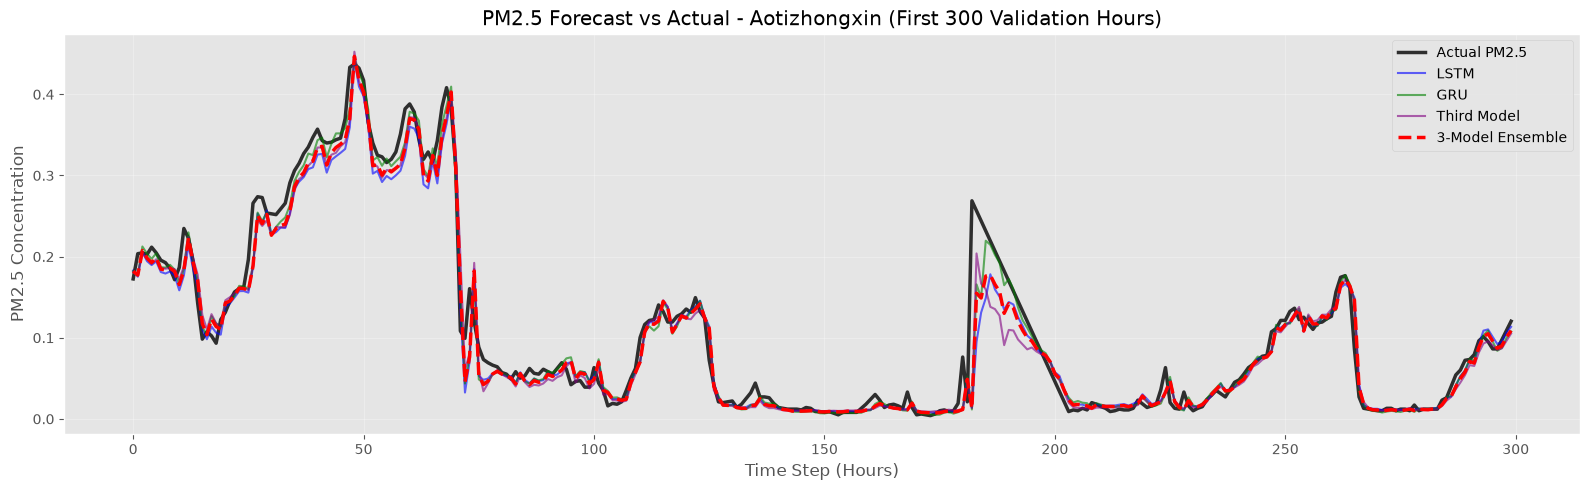

------------------------------------------------------------
Station: Changping
  LSTM RMSE:              0.0168
  GRU RMSE:               0.0162
  Third Model RMSE:       0.0169
  3-Model Ensemble RMSE:  0.0163
------------------------------------------------------------


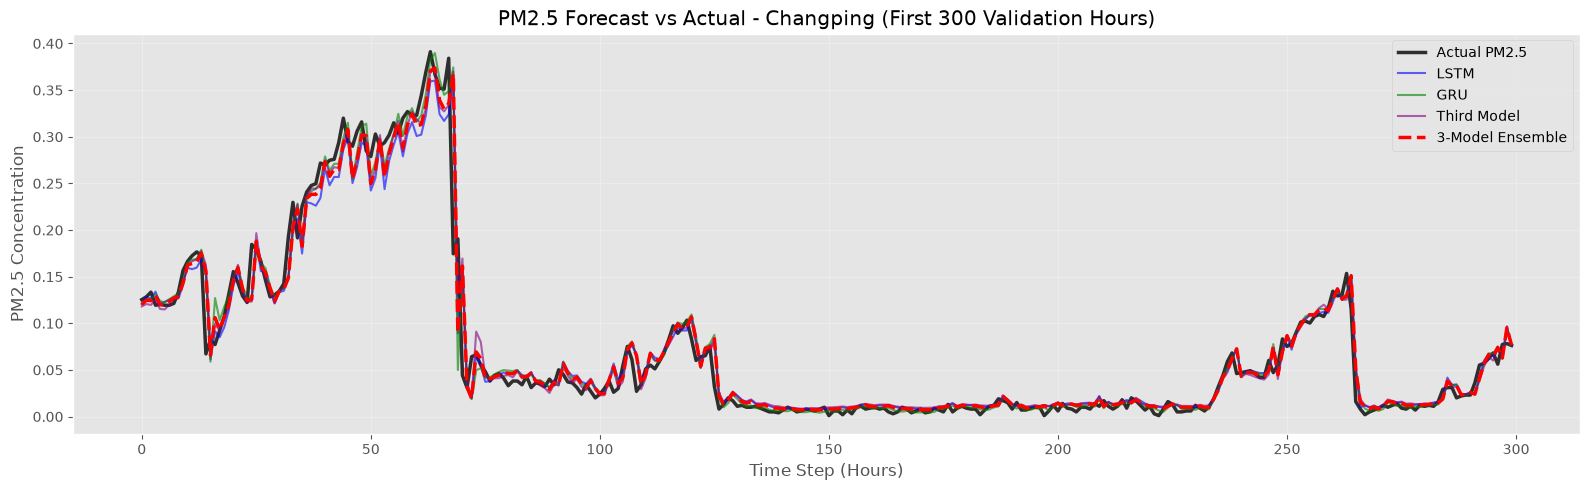

------------------------------------------------------------
Station: Dingling
  LSTM RMSE:              0.0181
  GRU RMSE:               0.0174
  Third Model RMSE:       0.0176
  3-Model Ensemble RMSE:  0.0174
------------------------------------------------------------


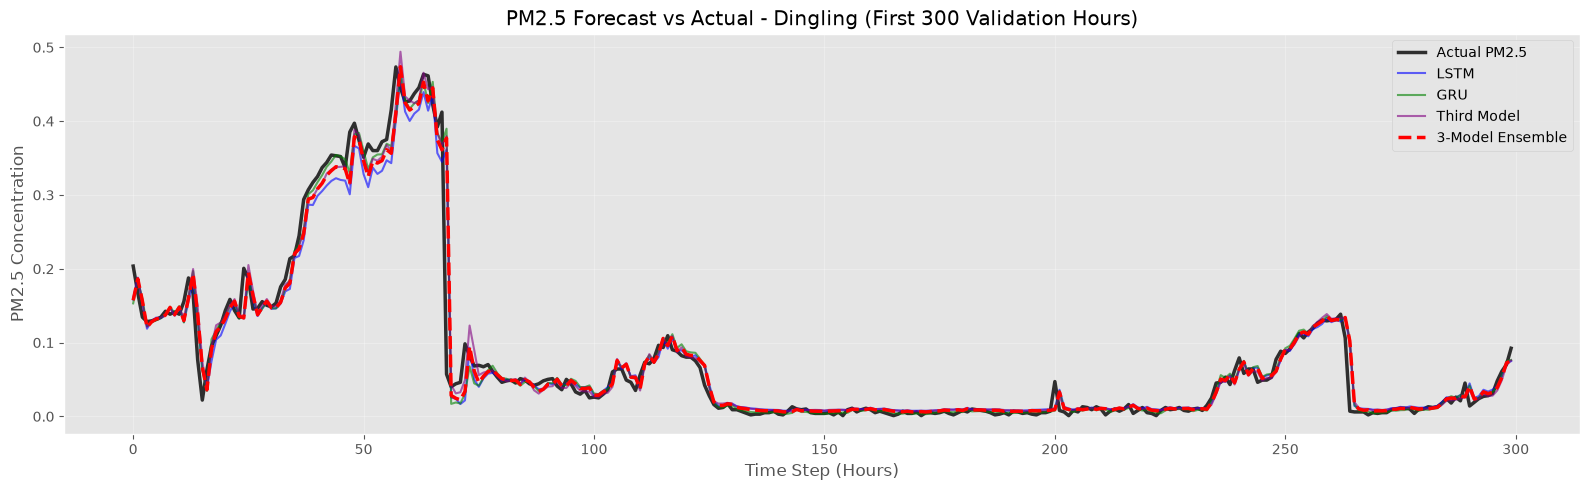

------------------------------------------------------------
Station: Dongsi
  LSTM RMSE:              0.0197
  GRU RMSE:               0.0192
  Third Model RMSE:       0.0201
  3-Model Ensemble RMSE:  0.0192
------------------------------------------------------------


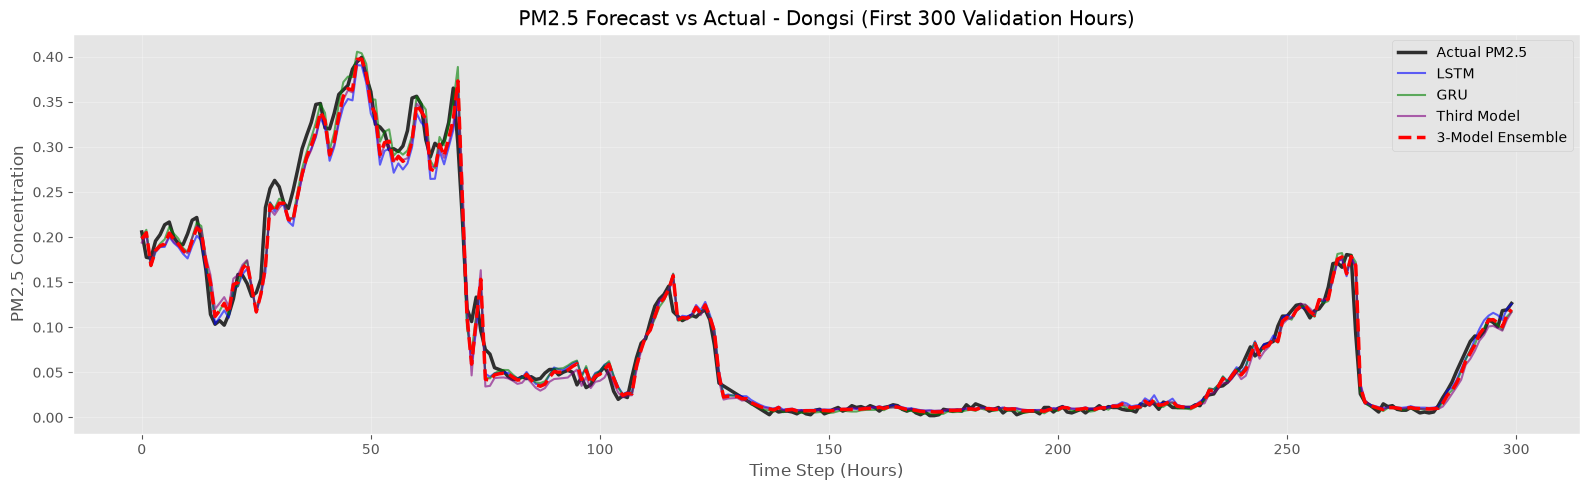

------------------------------------------------------------
Station: Guanyuan
  LSTM RMSE:              0.0181
  GRU RMSE:               0.0174
  Third Model RMSE:       0.0183
  3-Model Ensemble RMSE:  0.0175
------------------------------------------------------------


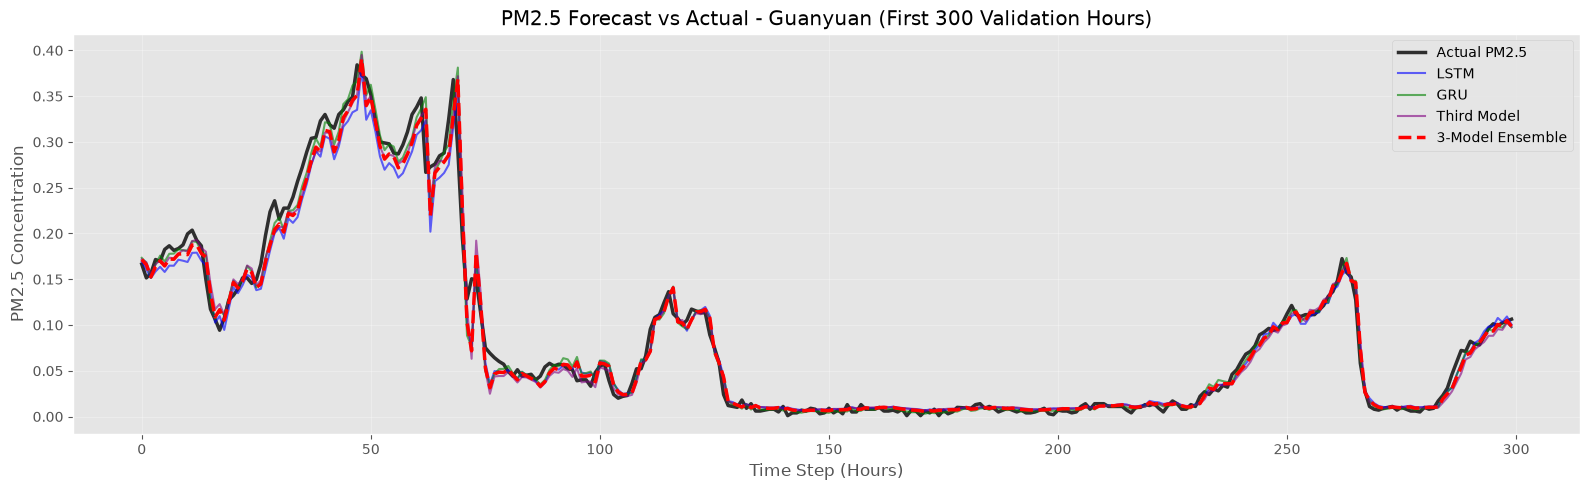

------------------------------------------------------------
Station: Gucheng
  LSTM RMSE:              0.0191
  GRU RMSE:               0.0183
  Third Model RMSE:       0.0193
  3-Model Ensemble RMSE:  0.0185
------------------------------------------------------------


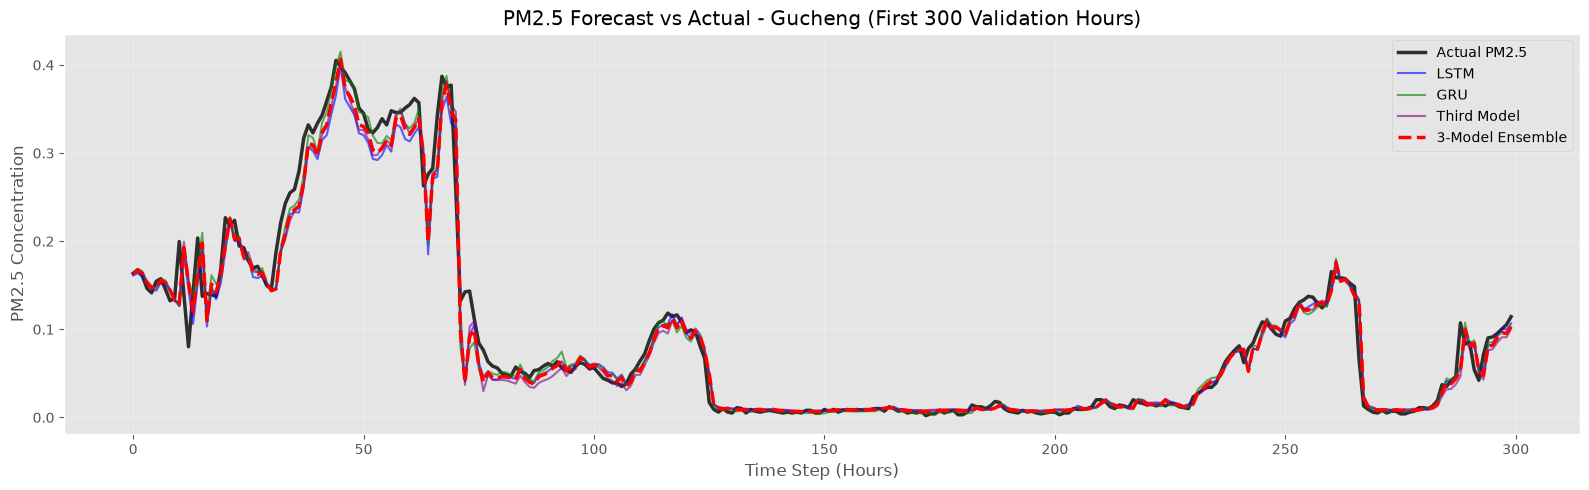

------------------------------------------------------------
Station: Huairou
  LSTM RMSE:              0.0167
  GRU RMSE:               0.0160
  Third Model RMSE:       0.0169
  3-Model Ensemble RMSE:  0.0162
------------------------------------------------------------


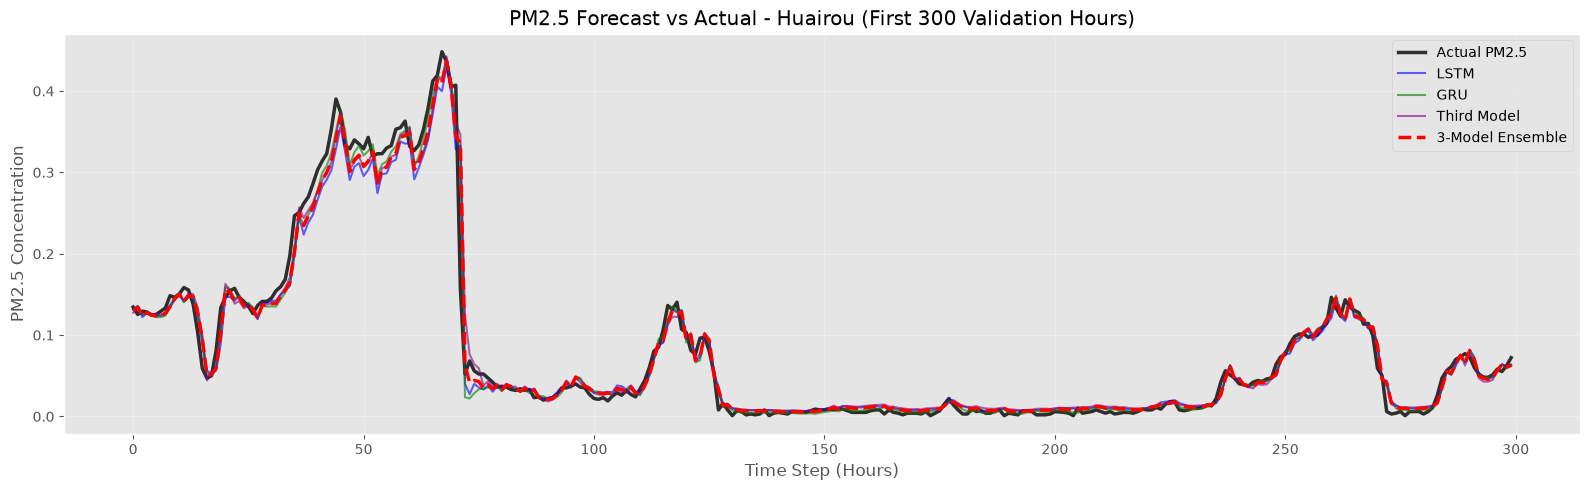

------------------------------------------------------------
Station: Nongzhanguan
  LSTM RMSE:              0.0178
  GRU RMSE:               0.0172
  Third Model RMSE:       0.0179
  3-Model Ensemble RMSE:  0.0172
------------------------------------------------------------


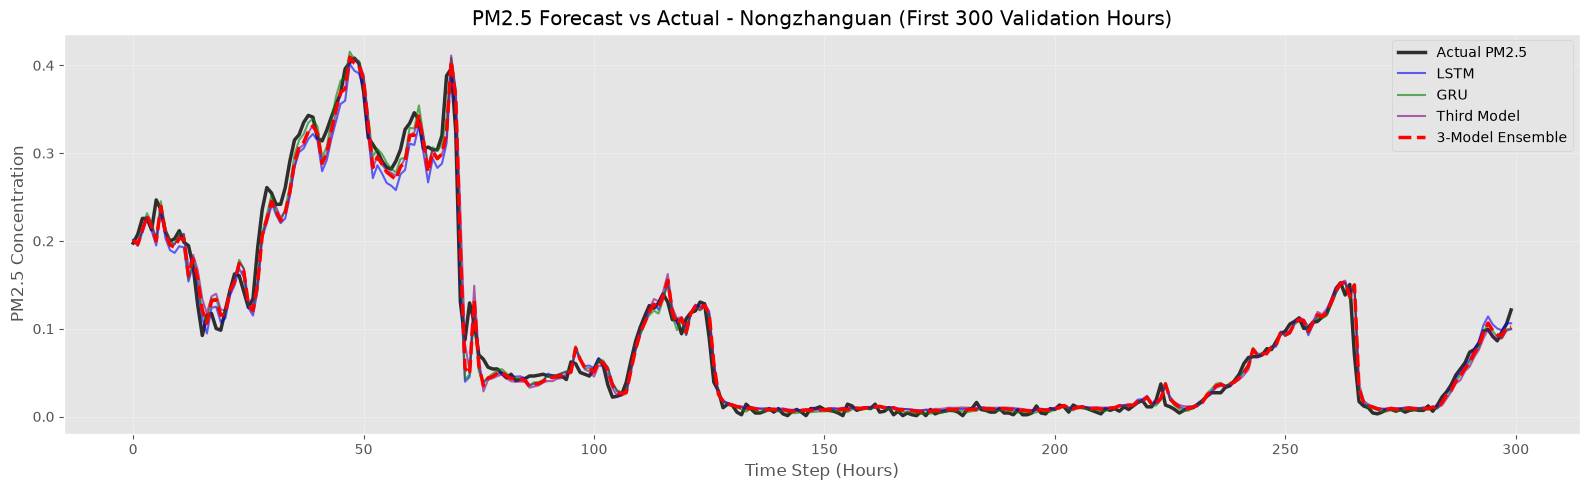

------------------------------------------------------------
Station: Shunyi
  LSTM RMSE:              0.0181
  GRU RMSE:               0.0173
  Third Model RMSE:       0.0188
  3-Model Ensemble RMSE:  0.0177
------------------------------------------------------------


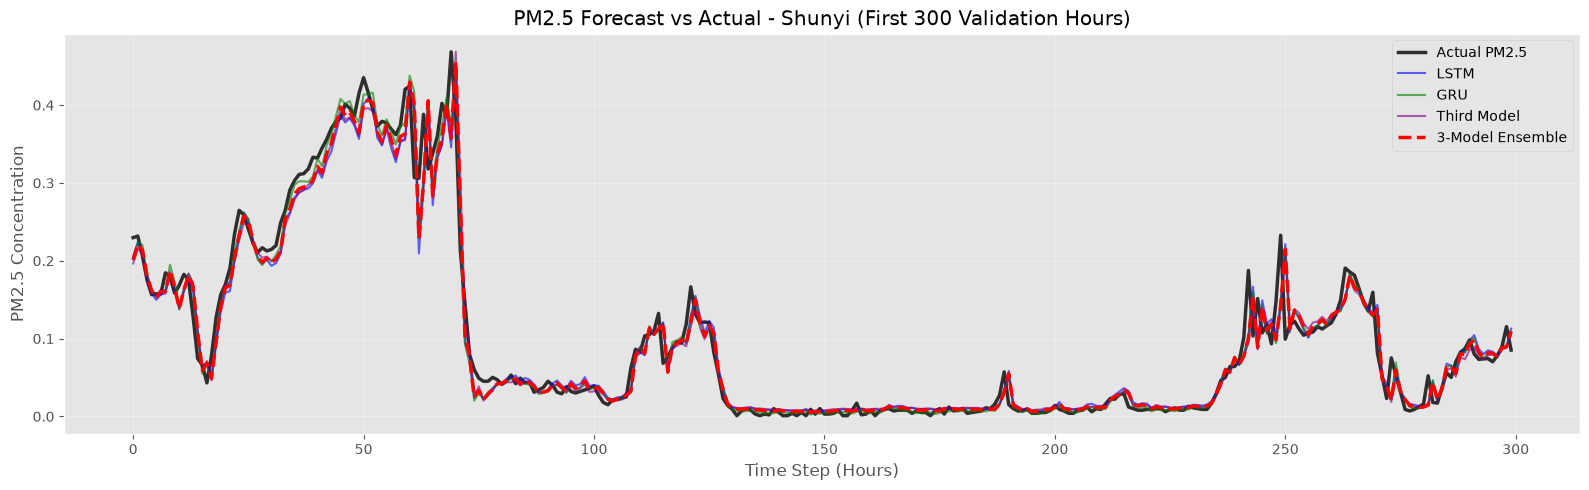

------------------------------------------------------------
Station: Tiantan
  LSTM RMSE:              0.0167
  GRU RMSE:               0.0158
  Third Model RMSE:       0.0169
  3-Model Ensemble RMSE:  0.0160
------------------------------------------------------------


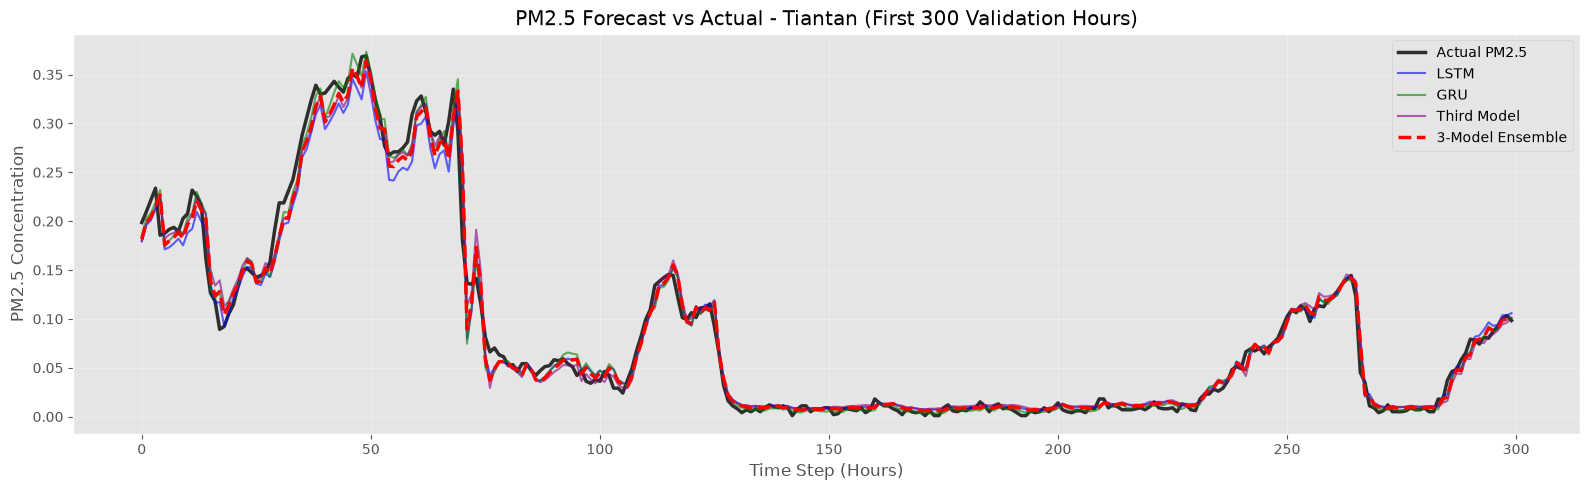

------------------------------------------------------------
Station: Wanliu
  LSTM RMSE:              0.0170
  GRU RMSE:               0.0165
  Third Model RMSE:       0.0173
  3-Model Ensemble RMSE:  0.0165
------------------------------------------------------------


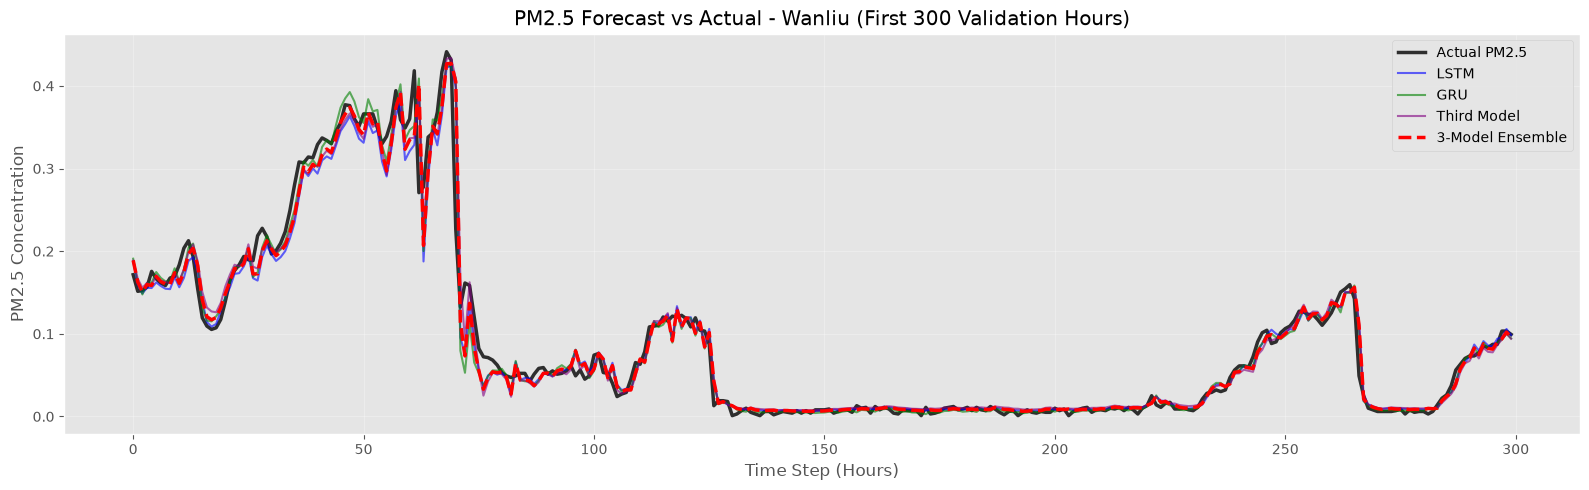

------------------------------------------------------------
Station: Wanshouxigong
  LSTM RMSE:              0.0202
  GRU RMSE:               0.0195
  Third Model RMSE:       0.0205
  3-Model Ensemble RMSE:  0.0196
------------------------------------------------------------


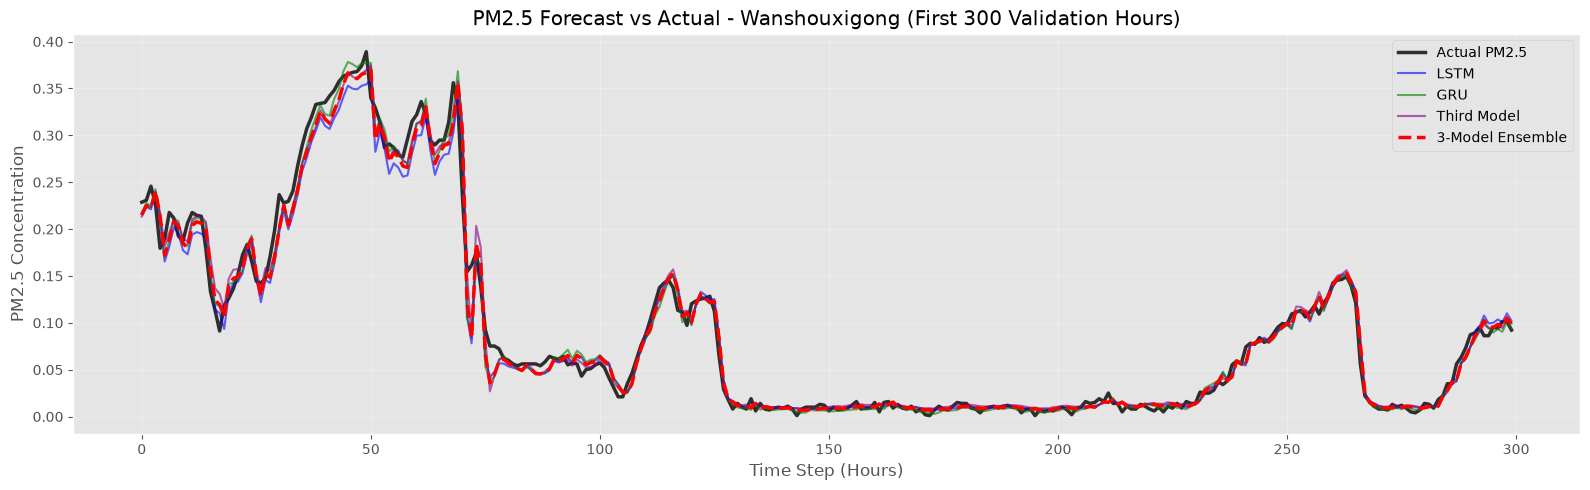

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Map flat prediction arrays back to individual stations
station_indices = {}
current_idx = 0

for station_name, group in val_df.groupby('station'):
    num_sequences = len(group) - window_size
    
    if num_sequences > 0:
        station_indices[station_name] = (
            current_idx,
            current_idx + num_sequences
        )
        current_idx += num_sequences


# 2. Iterate through each station, calculate metrics, and plot
plot_window = 300  # First 300 validation hours per station

for station_name, (start_idx, end_idx) in station_indices.items():

    # Slice actual and predictions for current station
    y_actual_station = y_val_actual[start_idx:end_idx]

    y_lstm_station = lstm_preds[start_idx:end_idx]
    y_gru_station = gru_preds[start_idx:end_idx]
    y_model_station = model_preds[start_idx:end_idx]

    y_ens_station = ensemble_preds[start_idx:end_idx]


    # Calculate RMSE
    rmse_lstm = np.sqrt(
        mean_squared_error(y_actual_station, y_lstm_station)
    )

    rmse_gru = np.sqrt(
        mean_squared_error(y_actual_station, y_gru_station)
    )

    rmse_model = np.sqrt(
        mean_squared_error(y_actual_station, y_model_station)
    )

    rmse_ens = np.sqrt(
        mean_squared_error(y_actual_station, y_ens_station)
    )


    # Print station results
    print("-" * 60)
    print(f"Station: {station_name}")
    print(f"  LSTM RMSE:              {rmse_lstm:.4f}")
    print(f"  GRU RMSE:               {rmse_gru:.4f}")
    print(f"  Third Model RMSE:       {rmse_model:.4f}")
    print(f"  3-Model Ensemble RMSE:  {rmse_ens:.4f}")
    print("-" * 60)


    # Plot predictions
    plt.figure(figsize=(16, 5))

    plt.plot(
        y_actual_station[:plot_window],
        label='Actual PM2.5',
        color='black',
        linewidth=2.5,
        alpha=0.8
    )

    plt.plot(
        y_lstm_station[:plot_window],
        label='LSTM',
        color='blue',
        alpha=0.6,
        linewidth=1.5
    )

    plt.plot(
        y_gru_station[:plot_window],
        label='GRU',
        color='green',
        alpha=0.6,
        linewidth=1.5
    )

    plt.plot(
        y_model_station[:plot_window],
        label='Third Model',
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    plt.plot(
        y_ens_station[:plot_window],
        label='3-Model Ensemble',
        color='red',
        linestyle='--',
        linewidth=2.5
    )


    plt.title(
        f'PM2.5 Forecast vs Actual - {station_name} '
        f'(First {plot_window} Validation Hours)'
    )

    plt.xlabel('Time Step (Hours)')
    plt.ylabel('PM2.5 Concentration')

    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [26]:
import pandas as pd
import numpy as np

# Make sure these lists are defined (matching your training script)
lags = [1, 2, 3, 6, 12, 24]
windows = [3, 6, 12, 24]
ewm_spans = [3, 6, 12, 24]

# 1. Load Kaggle test data
test_kaggle = pd.read_csv('test.csv')

raw_cols = [
    'year', 'month', 'day', 'hour',
    'PM2.5', 'PM10', 'SO2', 'NO2',
    'CO', 'O3', 'TEMP', 'PRES',
    'DEWP', 'RAIN', 'wd', 'WSPM'
]


# 2. Convert flattened test data into long format
print("Un-flattening test data...")
records = []

for idx, row in test_kaggle.iterrows():
    window_id = row['id']
    station_name = row['station']

    for step, lag in enumerate(range(24, 0, -1)):
        record = {
            'row_idx': idx,
            'step_idx': step,
            'id': window_id,
            'station': station_name
        }

        for col in raw_cols:
            col_name = f"{col}_lag_{lag}"
            record[col] = (
                row[col_name]
                if col_name in test_kaggle.columns
                else np.nan
            )
        records.append(record)

long_test_df = pd.DataFrame(records)



# 3. Missing value handling
def impute_test_window(group):
    num_cols = group.select_dtypes(include=[np.number]).columns
    group[num_cols] = (
        group[num_cols]
        .interpolate(method='linear', limit_direction='both')
        .ffill()
        .bfill()
    )
    group['wd'] = group['wd'].ffill().bfill()
    return group

long_test_df = (
    long_test_df
    .groupby('row_idx', group_keys=False)
    .apply(impute_test_window)
)



# 4. Feature Engineering (Exactly matching training steps)
def engineer_test_features(group):
    first_row = group.iloc[[0]].copy()
    padding = pd.concat([first_row] * 24, ignore_index=True)
    extended_group = pd.concat([padding, group], ignore_index=True)

    # Lags
    for lag in lags:
        extended_group[f'PM25_lag_{lag}'] = extended_group['PM2.5'].shift(lag)

    # Rolling Statistics
    for w in windows:
        shifted_pm25 = extended_group['PM2.5'].shift(1)
        
        extended_group[f'PM25_roll_mean_{w}'] = shifted_pm25.rolling(window=w).mean()
        extended_group[f'PM25_roll_std_{w}'] = shifted_pm25.rolling(window=w).std()
        extended_group[f'PM25_roll_min_{w}'] = shifted_pm25.rolling(w).min()
        extended_group[f'PM25_roll_max_{w}'] = shifted_pm25.rolling(w).max()
        extended_group[f'PM25_roll_median_{w}'] = shifted_pm25.rolling(w).median()
        extended_group[f'PM25_roll_q25_{w}'] = shifted_pm25.rolling(w).quantile(0.25)
        extended_group[f'PM25_roll_q75_{w}'] = shifted_pm25.rolling(w).quantile(0.75)

    # Exponential Moving Average
    for span in ewm_spans:
        extended_group[f'PM25_ewm_mean_{span}'] = (
            extended_group['PM2.5']
            .shift(1)
            .ewm(span=span, adjust=False)
            .mean()
        )

    # Differences
    extended_group['PM25_diff1'] = extended_group['PM2.5'].shift(1).diff(1)
    extended_group['PM25_diff24'] = extended_group['PM2.5'].shift(1).diff(24)

    # Fill NaNs created by lag/rolling/diff before CV calculation
    extended_group = extended_group.ffill().bfill()

    # Rolling CV
    for w in windows:
        extended_group[f'PM25_cv_{w}'] = (
            extended_group[f'PM25_roll_std_{w}'] / 
            (extended_group[f'PM25_roll_mean_{w}'] + 1e-6)
        )

    return extended_group.iloc[24:]

print("Applying feature engineering...")
long_test_df = (
    long_test_df
    .groupby('row_idx', group_keys=False)
    .apply(engineer_test_features)
    .reset_index(drop=True)
)



# 5. Time & Date Features
long_test_df['hour_sin'] = np.sin(2 * np.pi * long_test_df['hour'] / 24)
long_test_df['hour_cos'] = np.cos(2 * np.pi * long_test_df['hour'] / 24)

long_test_df['month_sin'] = np.sin(2 * np.pi * long_test_df['month'] / 12)
long_test_df['month_cos'] = np.cos(2 * np.pi * long_test_df['month'] / 12)

long_test_df['date'] = pd.to_datetime(long_test_df[['year','month','day','hour']])
long_test_df['weekday'] = long_test_df['date'].dt.weekday

long_test_df['weekday_sin'] = np.sin(2 * np.pi * long_test_df['weekday'] / 7)
long_test_df['weekday_cos'] = np.cos(2 * np.pi * long_test_df['weekday'] / 7)



# 6. Wind Direction Encoding
long_test_df['wd_angle'] = long_test_df['wd'].map(wd_map).fillna(0)
long_test_df['wd_sin'] = np.sin(np.radians(long_test_df['wd_angle']))
long_test_df['wd_cos'] = np.cos(np.radians(long_test_df['wd_angle']))



# 7. Station One-Hot Encoding
for st_col in station_cols:
    st_name = st_col.replace('station_', '')
    long_test_df[st_col] = (long_test_df['station'] == st_name).astype(float)



# 8. Ratio & Interaction Features
eps = 1e-6
long_test_df['PM25_PM10_ratio'] = long_test_df['PM2.5'] / (long_test_df['PM10'] + eps)
long_test_df['NO2_SO2_ratio'] = long_test_df['NO2'] / (long_test_df['SO2'] + eps)
long_test_df['CO_O3_ratio'] = long_test_df['CO'] / (long_test_df['O3'] + eps)
long_test_df['PM10_minus_PM25'] = long_test_df['PM10'] - long_test_df['PM2.5']

long_test_df['TEMP_DEWP'] = long_test_df['TEMP'] * long_test_df['DEWP']
long_test_df['TEMP_WSPM'] = long_test_df['TEMP'] * long_test_df['WSPM']
long_test_df['CO_WSPM'] = long_test_df['CO'] * long_test_df['WSPM']
long_test_df['NO2_O3'] = long_test_df['NO2'] * long_test_df['O3']
long_test_df['TEMP_hour'] = long_test_df['TEMP'] * long_test_df['hour_sin']
long_test_df['PRES_TEMP'] = long_test_df['PRES'] * long_test_df['TEMP']



# 9. Station Hour Mean
long_test_df['station_hour_mean'] = (
    long_test_df.set_index(['station','hour'])
    .index.map(hour_station_mean)
)

long_test_df['station_hour_mean'] = long_test_df['station_hour_mean'].fillna(
    long_test_df['hour'].map(global_hour_mean)
)

long_test_df.replace([np.inf, -np.inf], np.nan, inplace=True)



# 10. Final Scaling
print("Checking NaNs...")
nan_count = long_test_df[all_features].isna().sum().sum()

if nan_count > 0:
    print(f"Found {nan_count} NaNs. Filling...")
    long_test_df = long_test_df.groupby("station", group_keys=False).apply(
        lambda x: x.ffill().bfill()
    ).fillna(0)

print("Scaling features...")
long_test_df[all_features] = feature_scaler.transform(long_test_df[all_features])

# Ensure correct ordering before reshaping
long_test_df = long_test_df.sort_values(by=['row_idx','step_idx'])

# Create model input tensor
X_test_submission = (
    long_test_df[all_features]
    .values
    .reshape(len(test_kaggle), 24, len(all_features))
)



# 11. Predictions from 3 models
print("Running inference...")
lstm_preds_test_scaled = lstm_model.predict(X_test_submission, batch_size=256)
gru_preds_test_scaled = gru_model.predict(X_test_submission, batch_size=256)
model_preds_test_scaled = model.predict(X_test_submission, batch_size=256)

# 3-model ensemble
ensemble_preds_test_scaled = (
    lstm_preds_test_scaled
    + gru_preds_test_scaled
    + model_preds_test_scaled
) / 3.0



# 12. Inverse scaling (FIXED METHOD)
print("Inverse transforming predictions using true original scale...")

# Find the exact column index of PM2.5 in your feature scaler
pm25_idx = all_features.index('PM2.5')

def restore_true_scale(preds_scaled_array):
    # Create a dummy array matching the scaler's expected shape
    dummy_array = np.zeros((len(preds_scaled_array), len(all_features)))
    
    # Place scaled predictions into the PM2.5 column slot
    dummy_array[:, pm25_idx] = preds_scaled_array.flatten()
    
    # Inverse transform using the feature scaler (which holds the correct min/max)
    unscaled_array = feature_scaler.inverse_transform(dummy_array)
    
    # Extract and return ONLY the unscaled PM2.5 values
    return unscaled_array[:, pm25_idx]


ensemble_preds_final = restore_true_scale(ensemble_preds_test_scaled)
lstm_preds_final = restore_true_scale(lstm_preds_test_scaled)
gru_preds_final = restore_true_scale(gru_preds_test_scaled)
model_preds_final = restore_true_scale(model_preds_test_scaled)


# Sanity check
print("\n--- Sanity Check ---")
print("LSTM scaled (0-1):", lstm_preds_test_scaled[:3].flatten())
print("Ensemble PM2.5 (Real Values):", ensemble_preds_final[:3])
print("--------------------")



# 13. Save submissions
print("Saving CSV files...")

sub_lstm = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': lstm_preds_final})
sub_gru = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': gru_preds_final})
sub_model = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': model_preds_final})
sub_ensemble = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': ensemble_preds_final})

sub_lstm.to_csv('submission_lstm.csv', index=False)
sub_gru.to_csv('submission_gru.csv', index=False)
sub_model.to_csv('submission_model.csv', index=False)
sub_ensemble.to_csv('submission_3model_ensemble.csv', index=False)

print("Done! Saved 4 submission files.")

Un-flattening test data...
Applying feature engineering...
Checking NaNs...
Found 3048 NaNs. Filling...
Scaling features...
Running inference...
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Inverse transforming predictions using true original scale...

--- Sanity Check ---
LSTM scaled (0-1): [0.18220375 0.15469536 0.3935247 ]
Ensemble PM2.5 (Real Values): [183.1961922  159.19271748 401.63672164]
--------------------
Saving CSV files...
Done! Saved 4 submission files.


In [27]:
# Save trained models

lstm_model.save("lstm_pm25_model.keras")

gru_model.save("gru_pm25_model.keras")

model.save("third_pm25_model.keras")


print("All 3 models saved successfully!")

All 3 models saved successfully!


In [28]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU detected:")
    for gpu in gpus:
        print(gpu)
else:
    print("\nNo GPU detected")

TensorFlow version: 2.21.0

GPU detected:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU')


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ===============================
# Prepare Test Sequences
# ===============================

# Use original unscaled merged df
test_part = df[df['date'] >= split_date].copy()

# Need previous 72 hours from training to avoid dropping the first 72 test predictions
history_part = df[df['date'] < split_date].copy()
history_tails = history_part.groupby('station').tail(window_size)

# Concat AND strictly sort by station and date to prevent sequence scrambling
test_input = pd.concat([history_tails, test_part], axis=0)
test_input = test_input.sort_values(by=['station', 'date']).reset_index(drop=True)

# Apply same scaling used during training
test_input[all_features] = feature_scaler.transform(test_input[all_features])
test_input['PM2.5_scaled'] = target_scaler.transform(test_input[['PM2.5']])

# Create sequences
X_test, y_test_scaled = create_sequences_per_station(
    test_input,
    feature_cols=all_features,
    target_col='PM2.5_scaled',
    window_size=window_size
)

print("Test shape:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test_scaled.shape}")

# ===============================
# Predict
# ===============================

y_pred_scaled = lstm_model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

# ===============================
# Inverse Scaling
# ===============================

# Reshape y_test_scaled to 2D array for the scaler
y_test_raw = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
y_pred_raw = target_scaler.inverse_transform(y_pred_scaled)

# ===============================
# Metrics
# ===============================

rmse_lstm_val_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_lstm_val_raw = mean_absolute_error(y_test_raw, y_pred_raw)

print(f"Validation LSTM RMSE (vs Raw): {rmse_lstm_val_raw:.4f}")
print(f"Validation LSTM MAE (vs Raw): {mae_lstm_val_raw:.4f}")

Test shape:
X_test: (105120, 24, 43)
y_test: (105120,)
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Validation LSTM RMSE (vs Raw): 0.02
Validation LSTM MAE (vs Raw): 0.01


        station                date  Actual_PM25  Predicted_PM25
0  Aotizhongxin 2016-03-01 00:00:00     0.061184        0.064982
1  Aotizhongxin 2016-03-01 01:00:00     0.075226        0.063807
2  Aotizhongxin 2016-03-01 02:00:00     0.083250        0.079633
3  Aotizhongxin 2016-03-01 03:00:00     0.092277        0.085989
4  Aotizhongxin 2016-03-01 04:00:00     0.117352        0.101373


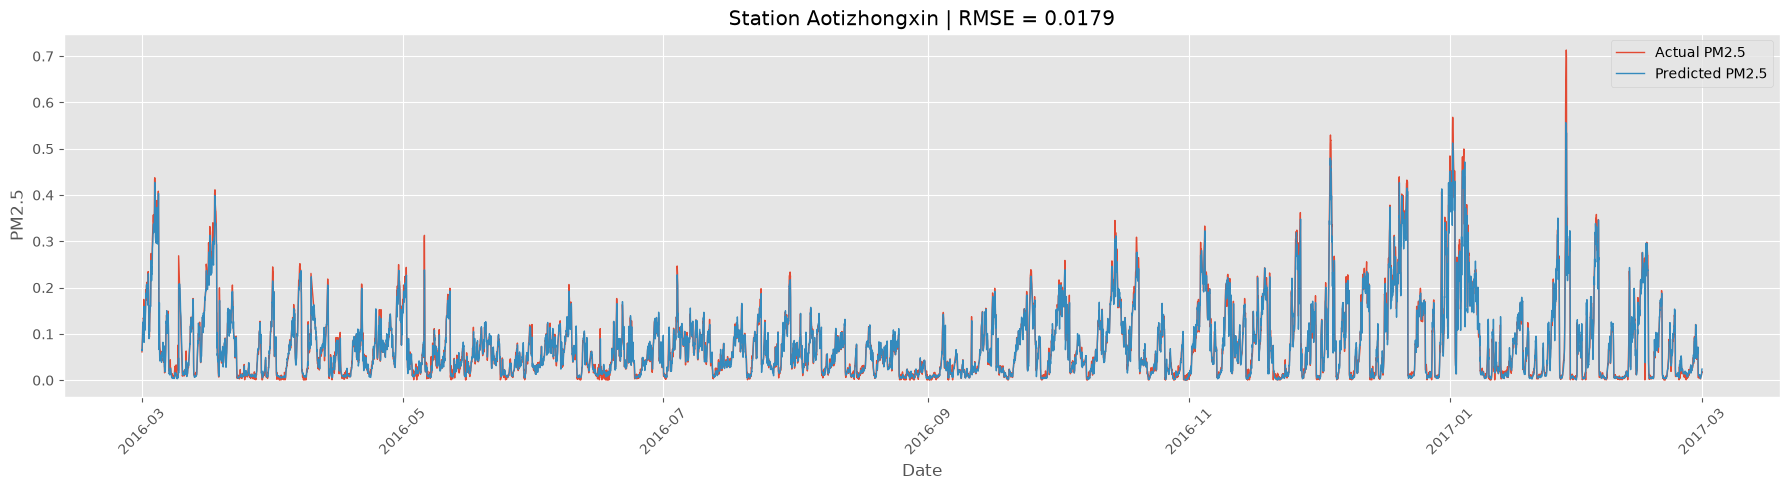

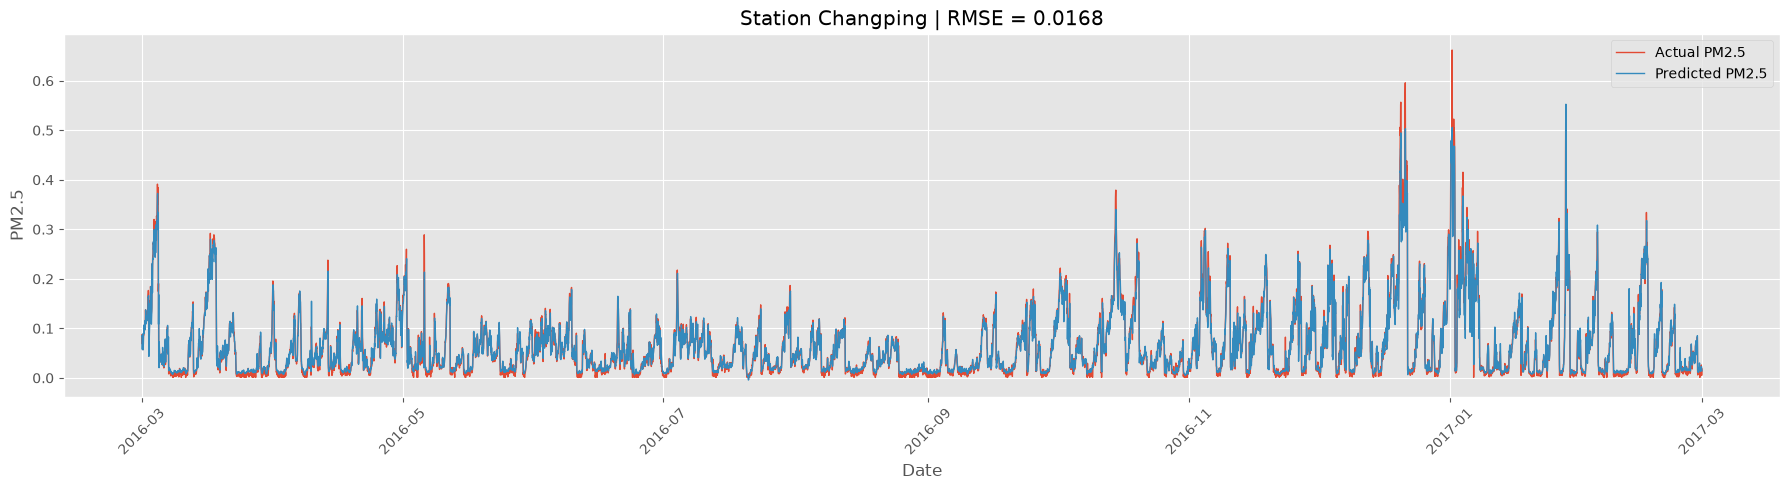

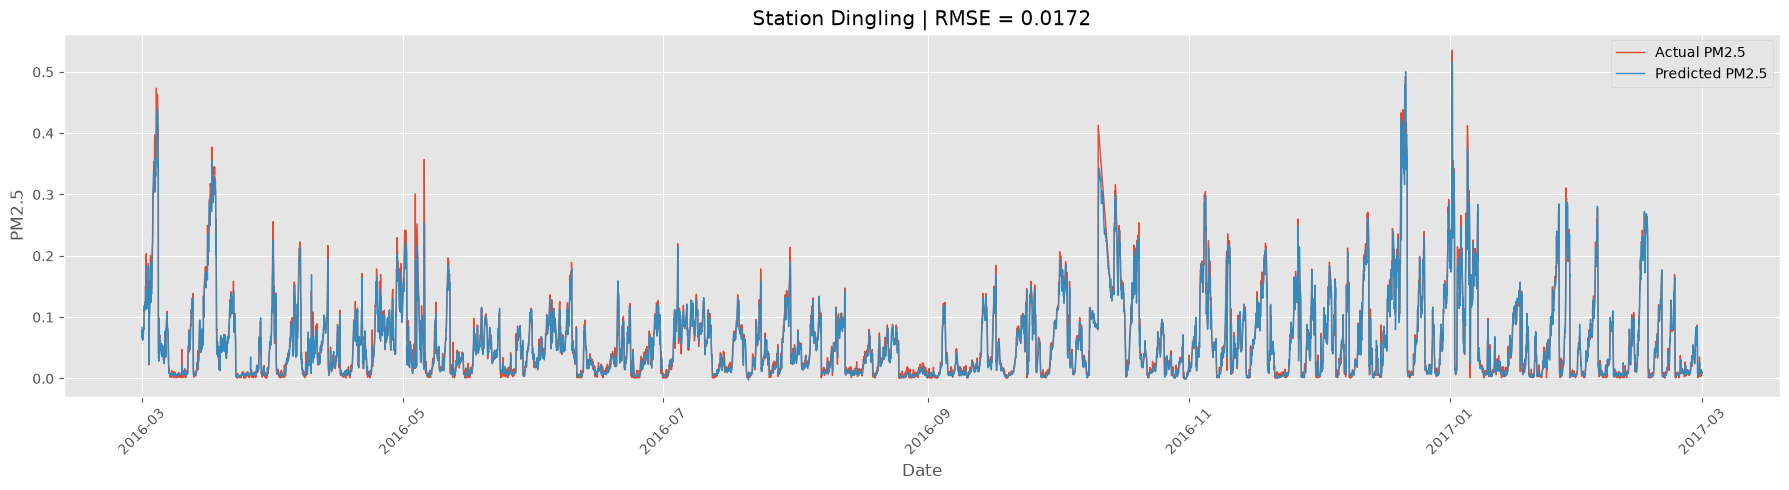

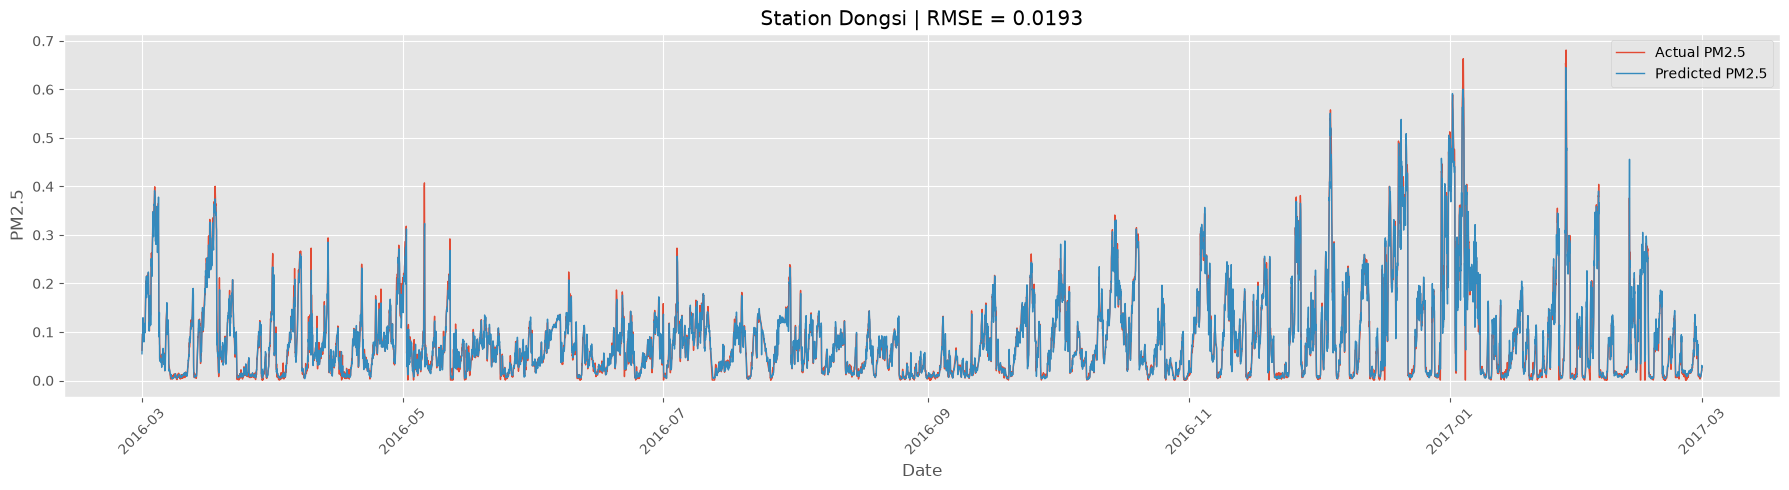

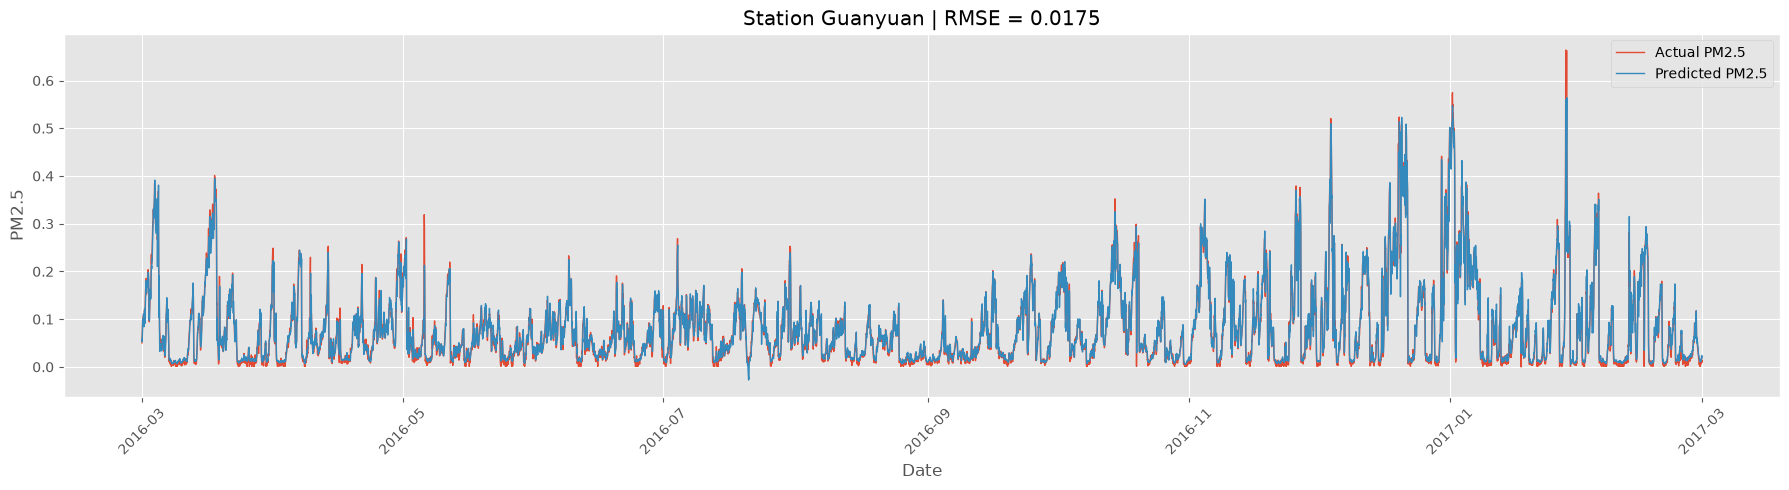

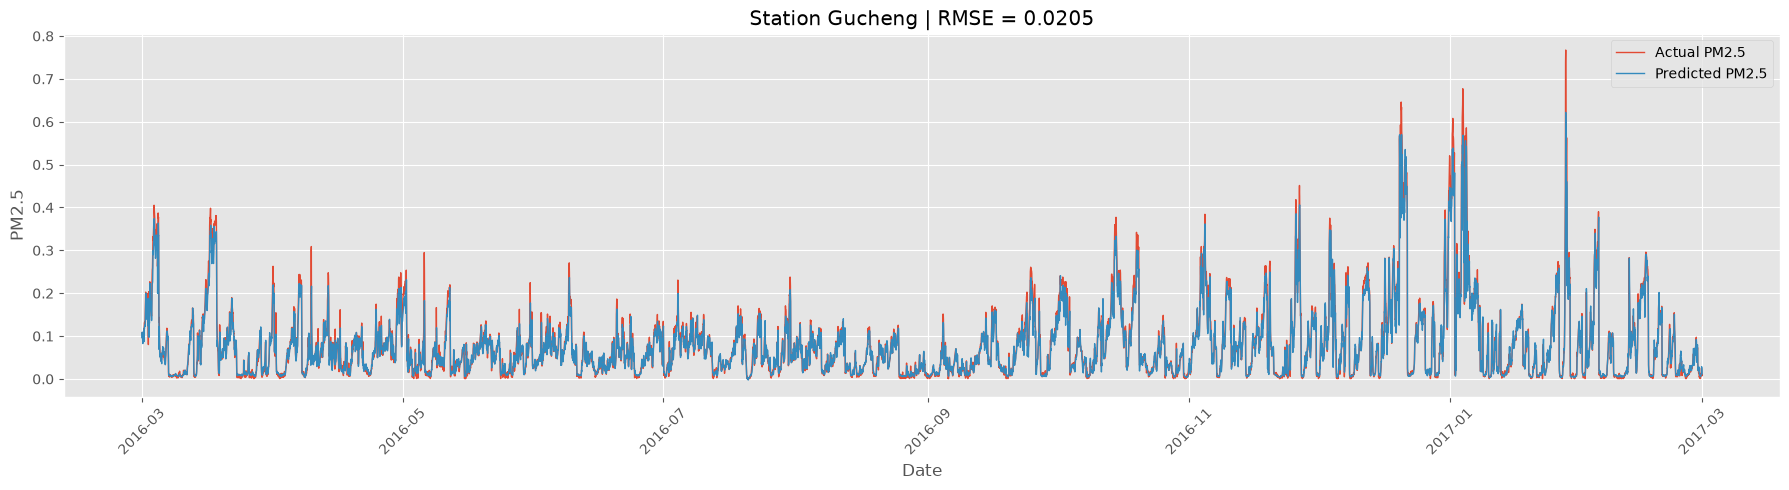

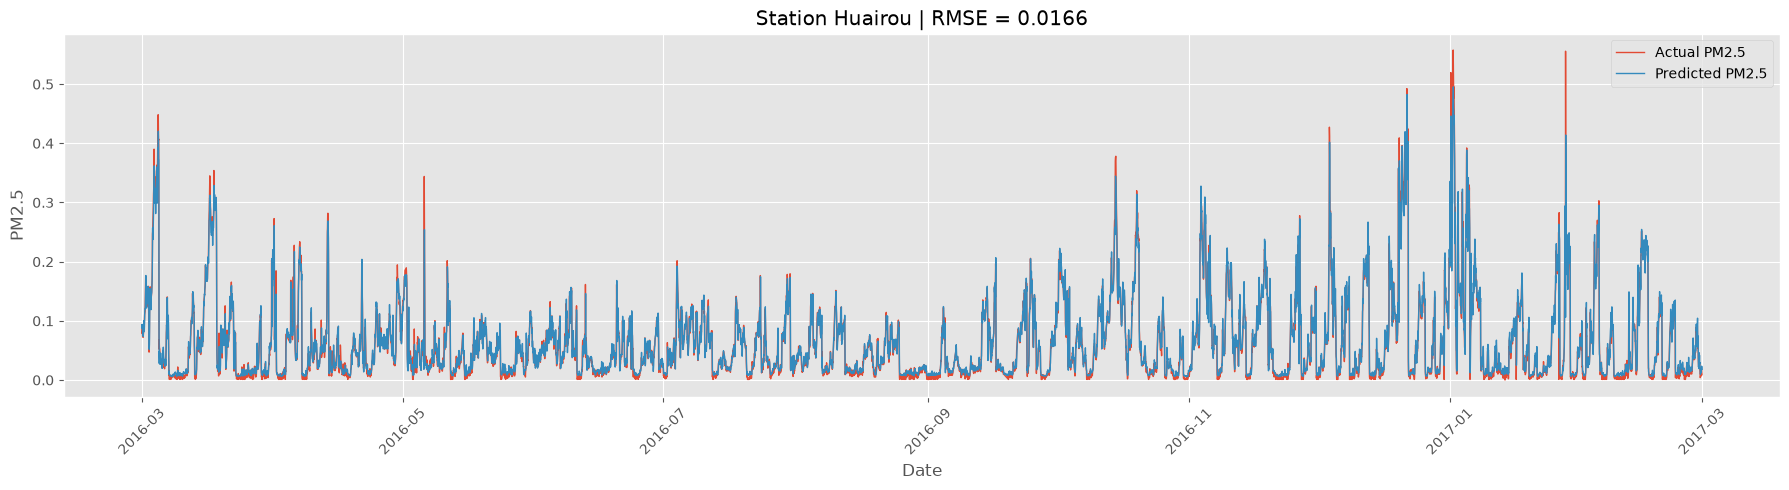

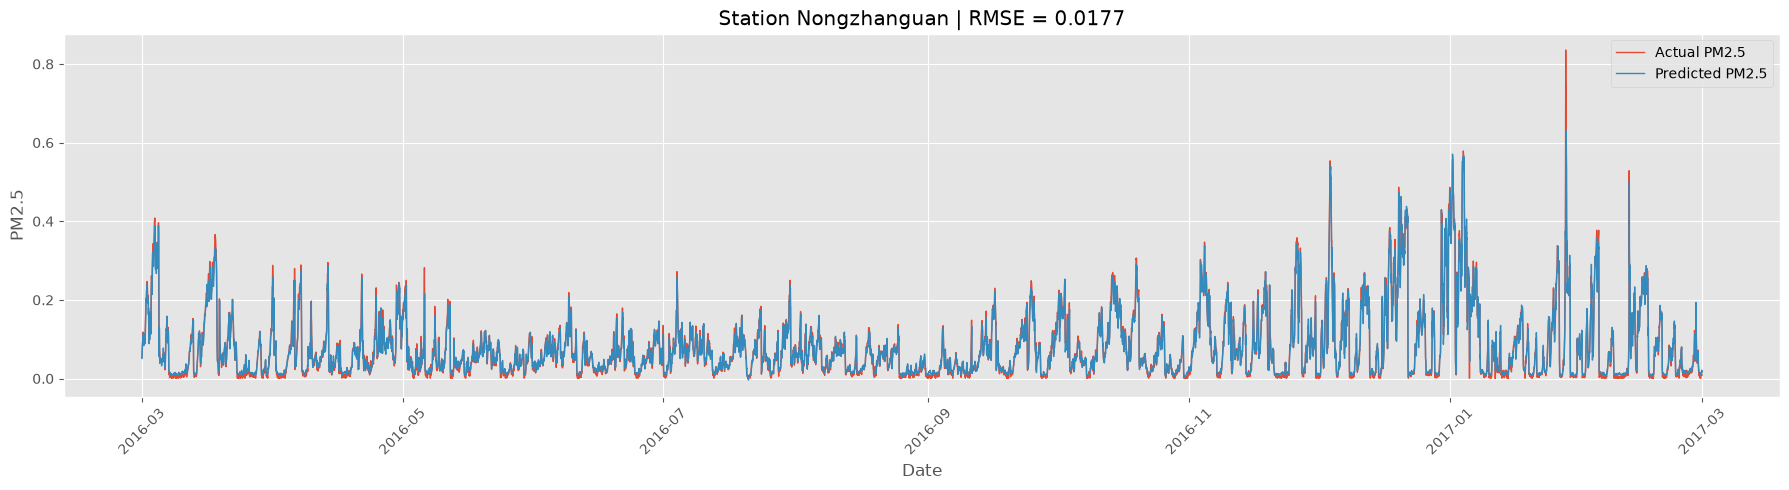

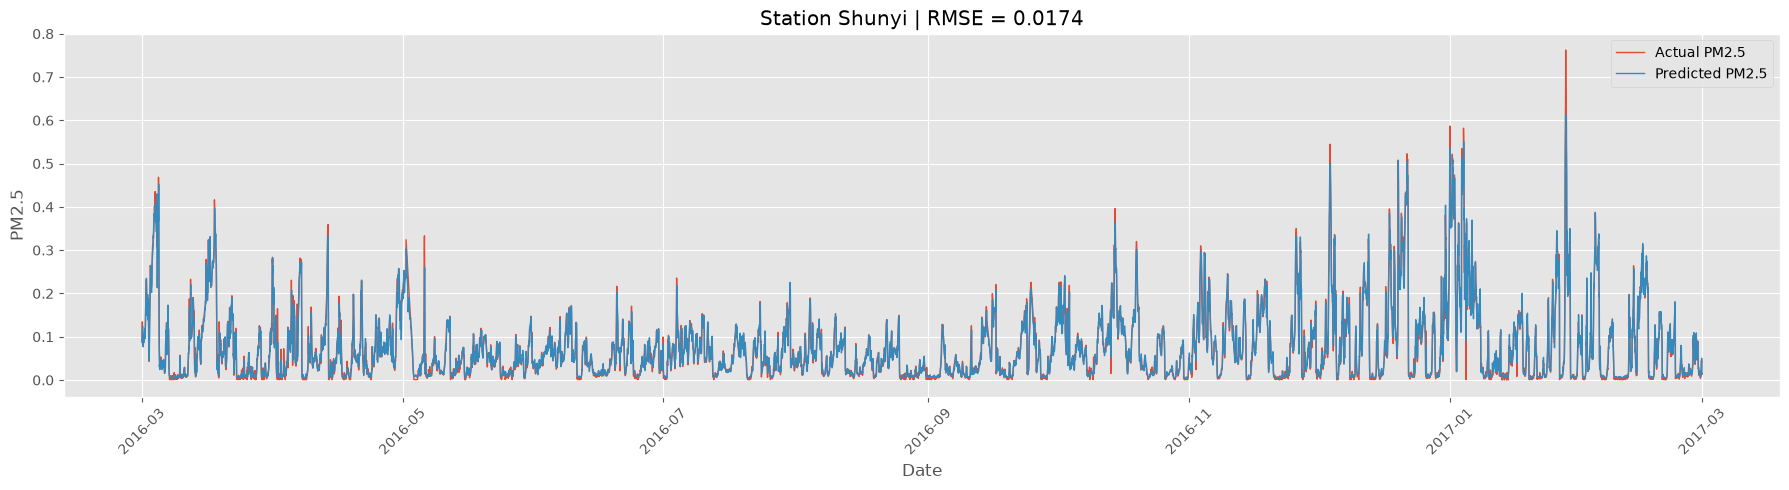

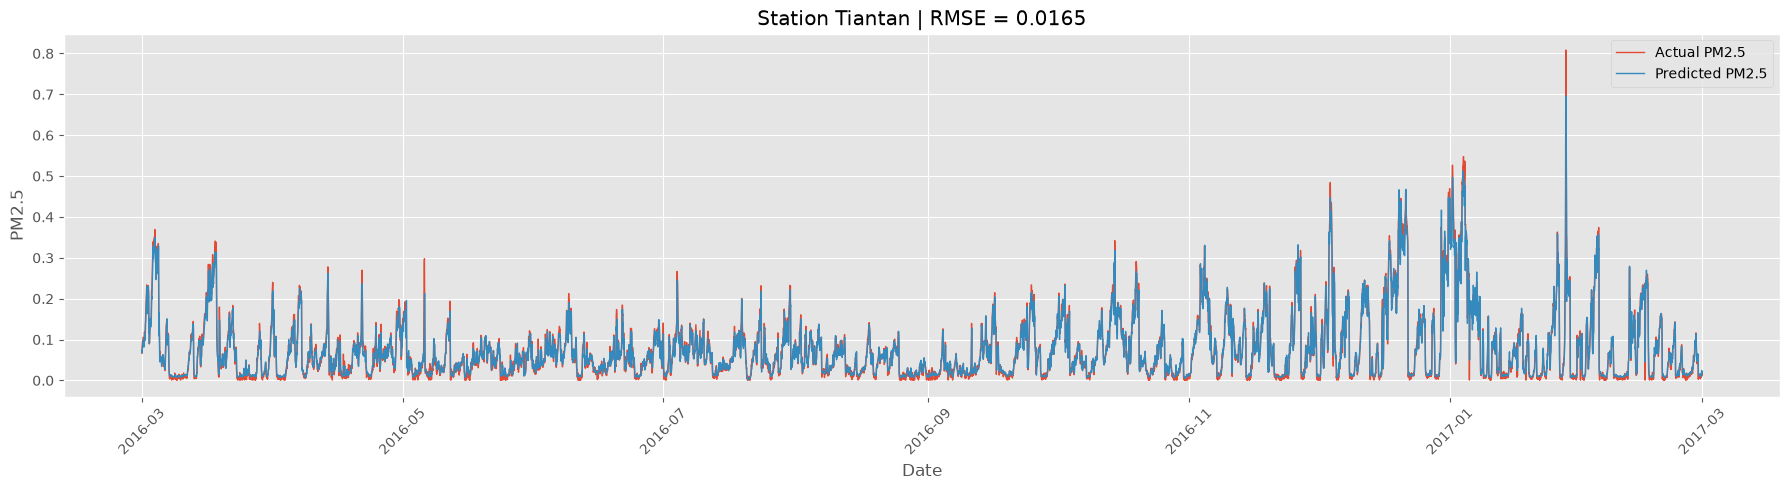

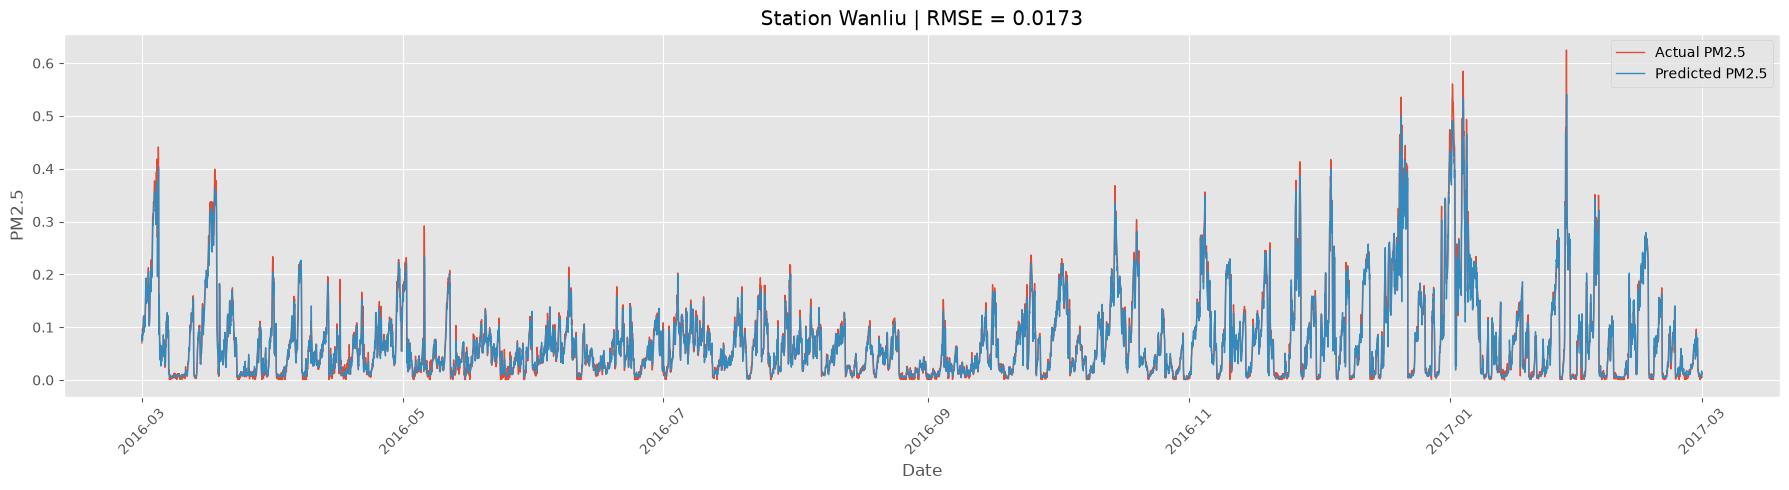

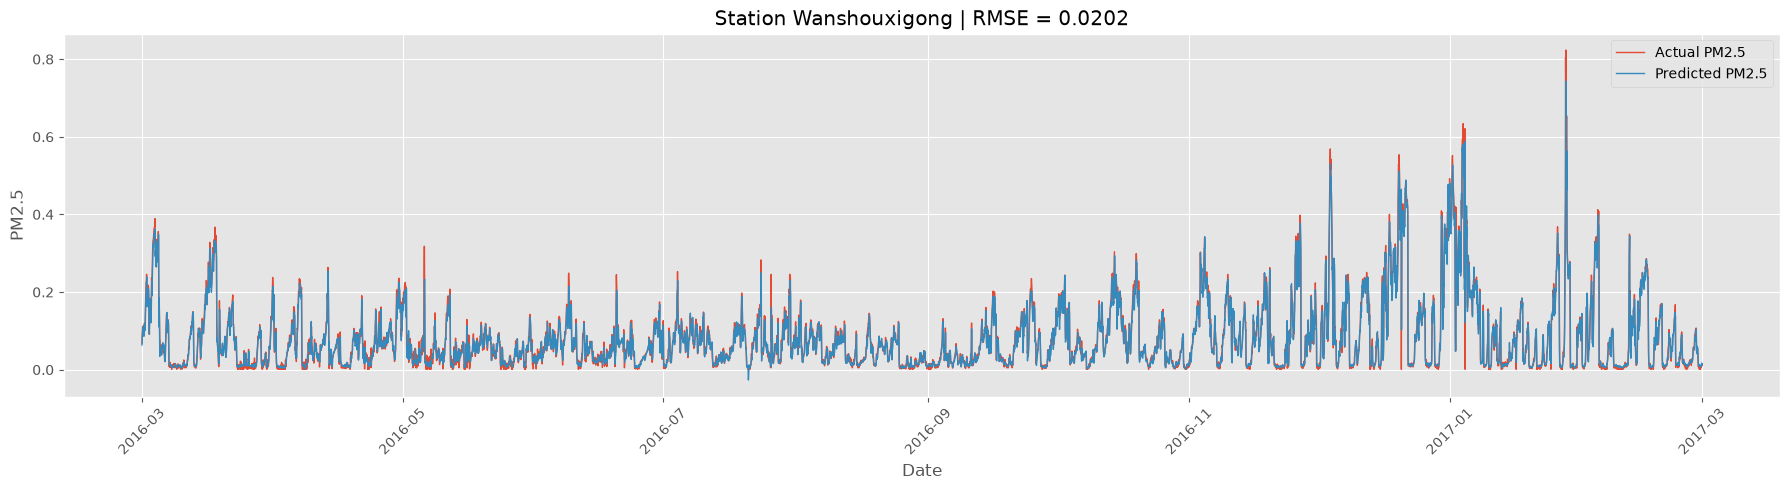


RMSE per station
----------------
Aotizhongxin: 0.0179
Changping: 0.0168
Dingling: 0.0172
Dongsi: 0.0193
Guanyuan: 0.0175
Gucheng: 0.0205
Huairou: 0.0166
Nongzhanguan: 0.0177
Shunyi: 0.0174
Tiantan: 0.0165
Wanliu: 0.0173
Wanshouxigong: 0.0202


In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd


# ============================================
# Create prediction dataframe with dates/stations
# ============================================

# Create test sequence metadata
def create_test_metadata(data, window_size=72):
    meta = []

    for station_name, group in data.groupby('station'):

        # Only keep prediction points (after window)
        dates = group['date'].values[window_size:]

        for d in dates:
            meta.append([
                station_name,
                d
            ])

    return pd.DataFrame(
        meta,
        columns=['station','date']
    )


# Use the same test_input used for X_test generation
test_meta = create_test_metadata(
    test_input,
    window_size
)


# Add predictions
results = test_meta.copy()

results['Actual_PM25'] = y_test_raw.flatten()
results['Predicted_PM25'] = y_pred_raw.flatten()


# Sort
results = results.sort_values(
    ['station','date']
)


print(results.head())



# ============================================
# Plot every station
# ============================================

stations = results['station'].unique()

station_rmse = {}


for station in stations:

    station_data = results[
        results['station'] == station
    ].copy()


    # Calculate RMSE
    rmse = np.sqrt(
        mean_squared_error(
            station_data['Actual_PM25'],
            station_data['Predicted_PM25']
        )
    )

    station_rmse[station] = rmse


    # Plot
    plt.figure(figsize=(18,5))

    plt.plot(
        station_data['date'],
        station_data['Actual_PM25'],
        label='Actual PM2.5',
        linewidth=1
    )

    plt.plot(
        station_data['date'],
        station_data['Predicted_PM25'],
        label='Predicted PM2.5',
        linewidth=1
    )


    plt.title(
        f"Station {station} | RMSE = {rmse:.4f}"
    )

    plt.xlabel("Date")
    plt.ylabel("PM2.5")

    plt.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()



# ============================================
# Print RMSE table
# ============================================

print("\nRMSE per station")
print("----------------")

for station, rmse in station_rmse.items():
    print(
        f"{station}: {rmse:.4f}"
    )

In [37]:
import pandas as pd
import numpy as np

# Make sure your previously defined lists are active
lags = [1, 2, 3, 6, 12, 24]
windows = [3, 6, 12, 24]

# 1. Load the Kaggle test data
test_kaggle = pd.read_csv('test.csv')
raw_cols = ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM']

# 2. Un-flatten into long-format (24 rows per window)
print("Un-flattening test data...")
records = []
for idx, row in test_kaggle.iterrows():
    window_id = row['id']
    station_name = row['station']
    for step, lag in enumerate(range(24, 0, -1)):
        record = {'row_idx': idx, 'step_idx': step, 'id': window_id, 'station': station_name}
        for col in raw_cols:
            col_name = f"{col}_lag_{lag}"
            record[col] = row[col_name] if col_name in test_kaggle.columns else np.nan
        records.append(record)

long_test_df = pd.DataFrame(records)

# 3. Impute Missing Values in raw columns
def impute_test_window(group):
    num_cols = group.select_dtypes(include=[np.number]).columns
    # Interpolate in both directions to ensure no NaNs remain
    group[num_cols] = group[num_cols].interpolate(method='linear', limit_direction='both').ffill().bfill()
    group['wd'] = group['wd'].ffill().bfill()
    return group

long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(impute_test_window)

# 4. Feature Engineering (WITH PADDING to fix the 0.0 values issue)
# We pad the 24h window by repeating the first row so that lag_24 doesn't return pure NaNs
def engineer_test_features(group):

    first_row = group.iloc[[0]].copy()

    padding = pd.concat(
        [first_row] * 24,
        ignore_index=True
    )

    extended_group = pd.concat(
        [padding, group],
        ignore_index=True
    )


    # -------------------------------
    # Lag Features
    # -------------------------------
    for lag in lags:

        extended_group[f'PM25_lag_{lag}'] = (
            extended_group['PM2.5']
            .shift(lag)
        )


    # -------------------------------
    # Rolling Features
    # -------------------------------
    for w in windows:

        shifted_pm = (
            extended_group['PM2.5']
            .shift(1)
        )

        extended_group[f'PM25_roll_mean_{w}'] = (
            shifted_pm
            .rolling(w)
            .mean()
        )

        extended_group[f'PM25_roll_std_{w}'] = (
            shifted_pm
            .rolling(w)
            .std()
        )

        extended_group[f'PM25_roll_min_{w}'] = (
            shifted_pm
            .rolling(w)
            .min()
        )

        extended_group[f'PM25_roll_max_{w}'] = (
            shifted_pm
            .rolling(w)
            .max()
        )

        extended_group[f'PM25_roll_median_{w}'] = (
            shifted_pm
            .rolling(w)
            .median()
        )


        # Quantiles
        extended_group[f'PM25_roll_q25_{w}'] = (
            shifted_pm
            .rolling(w)
            .quantile(0.25)
        )

        extended_group[f'PM25_roll_q75_{w}'] = (
            shifted_pm
            .rolling(w)
            .quantile(0.75)
        )


    # -------------------------------
    # EMA Features
    # -------------------------------
    for span in ewm_spans:

        extended_group[f'PM25_ewm_mean_{span}'] = (
            extended_group['PM2.5']
            .shift(1)
            .ewm(
                span=span,
                adjust=False
            )
            .mean()
        )


    # -------------------------------
    # Difference Features
    # -------------------------------
    extended_group['PM25_diff1'] = (
        extended_group['PM2.5']
        .shift(1)
        .diff(1)
    )

    extended_group['PM25_diff24'] = (
        extended_group['PM2.5']
        .shift(1)
        .diff(24)
    )


    # -------------------------------
    # Fill NaN
    # -------------------------------
    extended_group = extended_group.ffill().bfill()



    # -------------------------------
    # Rolling CV
    # -------------------------------
    for w in windows:

        extended_group[f'PM25_cv_{w}'] = (
            extended_group[f'PM25_roll_std_{w}'] /
            (
                extended_group[f'PM25_roll_mean_{w}']
                +
                1e-6
            )
        )



    # -------------------------------
    # Ratio Features
    # -------------------------------
    eps = 1e-6

    extended_group['PM25_PM10_ratio'] = (
        extended_group['PM2.5'] /
        (extended_group['PM10'] + eps)
    )

    extended_group['NO2_SO2_ratio'] = (
        extended_group['NO2'] /
        (extended_group['SO2'] + eps)
    )

    extended_group['CO_O3_ratio'] = (
        extended_group['CO'] /
        (extended_group['O3'] + eps)
    )

    extended_group['PM10_minus_PM25'] = (
        extended_group['PM10'] -
        extended_group['PM2.5']
    )


    # -------------------------------
    # Interaction Features
    # -------------------------------

    extended_group['TEMP_DEWP'] = (
        extended_group['TEMP'] *
        extended_group['DEWP']
    )

    extended_group['TEMP_WSPM'] = (
        extended_group['TEMP'] *
        extended_group['WSPM']
    )

    extended_group['CO_WSPM'] = (
        extended_group['CO'] *
        extended_group['WSPM']
    )

    extended_group['NO2_O3'] = (
        extended_group['NO2'] *
        extended_group['O3']
    )

    extended_group['TEMP_hour'] = (
        extended_group['TEMP'] *
        np.sin(
            2*np.pi*extended_group['hour']/24
        )
    )

    extended_group['PRES_TEMP'] = (
        extended_group['PRES'] *
        extended_group['TEMP']
    )


    return extended_group.iloc[24:]
print("Applying feature engineering...")
long_test_df = long_test_df.groupby('row_idx', group_keys=False).apply(engineer_test_features).reset_index(drop=True)

# 5. Cyclical Time & Station Encoding
long_test_df['hour_sin'] = np.sin(
    2*np.pi*long_test_df['hour']/24
)

long_test_df['hour_cos'] = np.cos(
    2*np.pi*long_test_df['hour']/24
)

long_test_df['month_sin'] = np.sin(2 * np.pi * long_test_df['month'] / 12)
long_test_df['month_cos'] = np.cos(2 * np.pi * long_test_df['month'] / 12)

long_test_df['date'] = pd.to_datetime(long_test_df[['year', 'month', 'day', 'hour']])
long_test_df['weekday'] = long_test_df['date'].dt.weekday

long_test_df['weekday_sin'] = np.sin(2 * np.pi * long_test_df['weekday'] / 7)
long_test_df['weekday_cos'] = np.cos(2 * np.pi * long_test_df['weekday'] / 7)

long_test_df['wd_angle'] = long_test_df['wd'].map(wd_map).fillna(0)
long_test_df['wd_sin'] = np.sin(np.radians(long_test_df['wd_angle']))
long_test_df['wd_cos'] = np.cos(np.radians(long_test_df['wd_angle']))

for st_col in station_cols:
    st_name = st_col.replace('station_', '')
    long_test_df[st_col] = (long_test_df['station'] == st_name).astype(float)

# 6. Scale Features & Reshape
print("Scaling features...")
long_test_df[all_features] = feature_scaler.transform(long_test_df[all_features])
long_test_df = long_test_df.sort_values(by=['row_idx', 'step_idx'])

# Recreate the 3D tensor for the LSTM/GRU models
X_test_submission = long_test_df[all_features].values.reshape(len(test_kaggle), 24, len(all_features))

# 7. Generate Scaled Predictions
print("Running inferences...")
lstm_preds_test_scaled = lstm_model.predict(X_test_submission, batch_size=256)
gru_preds_test_scaled = gru_model.predict(X_test_submission, batch_size=256)
ensemble_preds_test_scaled = (lstm_preds_test_scaled + gru_preds_test_scaled) / 2.0

# 8. Inverse Transform Back to Raw PM2.5 Scale using the correct feature_scaler
print("Reversing the scaling using original feature bounds...")

# Find exactly where PM2.5 is in the feature scaler's memory
pm25_idx = all_features.index('PM2.5')
pm25_min = feature_scaler.data_min_[pm25_idx]
pm25_max = feature_scaler.data_max_[pm25_idx]
pm25_range = pm25_max - pm25_min

# Manually apply the inverse transformation formula: X_raw = (X_scaled * Range) + Min
lstm_preds_final = (lstm_preds_test_scaled.flatten() * pm25_range) + pm25_min
gru_preds_final = (gru_preds_test_scaled.flatten() * pm25_range) + pm25_min
ensemble_preds_final = (ensemble_preds_test_scaled.flatten() * pm25_range) + pm25_min

# Sanity Check print out
print("\n--- Sanity Check ---")
print(f"Scaled LSTM predictions (first 3): {lstm_preds_test_scaled[:3].flatten()}")
print(f"Inverse Transformed PM2.5 (first 3): {lstm_preds_final[:3]}")
print("--------------------\n")

# 9. Build Kaggle-compliant CSVs
print("Saving CSVs...")
sub_lstm = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': lstm_preds_final})
sub_gru = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': gru_preds_final})
sub_ens = pd.DataFrame({'id': test_kaggle['id'], 'PM2.5': ensemble_preds_final})

sub_lstm.to_csv('submission_lstm.csv', index=False)
sub_gru.to_csv('submission_gru.csv', index=False)
sub_ens.to_csv('submission_ensemble.csv', index=False)

print("Done! The 3 CSV files have been properly un-scaled and saved.")

Un-flattening test data...
Applying feature engineering...
Scaling features...
Running inferences...
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Reversing the scaling using original feature bounds...

--- Sanity Check ---
Scaled LSTM predictions (first 3): [0.18032712 0.15785795 0.40912658]
Inverse Transformed PM2.5 (first 3): [181.78613609 159.38438064 409.89920002]
--------------------

Saving CSVs...
Done! The 3 CSV files have been properly un-scaled and saved.


In [44]:
# Save trained models
lstm_model.save("lstm_pm25_model.keras")
gru_model.save("gru_pm25_model.keras")

print("Models saved successfully!")

Models saved successfully!
